# ARIMA, LSTM, xLSTM, Transformer & Ensemble Models for Stock Price Forecasting
### Victor Radeny — 119368

## Overview
This notebook extends the original ARIMA + LSTM work to include two additional deep-learning architectures:
- **xLSTM** (Extended LSTM): an architectural evolution of the classic LSTM featuring exponential gating and improved memory mixing
- **Decoder-only Transformer**: the dominant architecture in modern sequence modelling, adapted for univariate/multivariate financial time series

For each deep learning model we build a **stacked ensemble** with ARIMA using Ridge Regression as the meta-learner, following the exact methodology already established in this notebook.

### Models Implemented
| Model | Type |
|---|---|
| ARIMA | Statistical |
| LSTM | Deep Learning (RNN) |
| xLSTM | Deep Learning (Extended RNN) |
| Decoder-only Transformer | Deep Learning (Attention) |
| ARIMA + LSTM | Ensemble |
| ARIMA + xLSTM | Ensemble |
| ARIMA + Transformer | Ensemble |

### Notebook Structure
1. Environment Setup & Reproducibility
2. Data Loading & EDA
3. ARIMA Modelling
4. Feature Engineering & Preprocessing
5. Feature Selection
6. Sliding Window Construction
7. LSTM — Architecture, Tuning, Training, Prediction
8. **xLSTM — Architecture, Tuning, Training, Prediction** *(new)*
9. **Decoder-only Transformer — Architecture, Tuning, Training, Prediction** *(new)*
10. Ensemble Construction (Ridge Meta-learner)
11. Evaluation & Comparison


---
## Environment Setup
Once the virtual machine for the Cloud GPU is running, check the status by running: `ssh -p port_number username@ip_address`. Sometimes, previous connections can prevent a new connection so run: `ssh-keygen -R [ip_address]:port_number` to remove old SSH keys.


This notebook is designed to run on a cloud GPU server and on a local CPU. To avoid any conflicts between existing packages and the ones we are installing, first we create a new virtual environment: `python3 -m venv venv` and activate it: `source venv/bin/activate`

 Then we install the required packages that are not part of Python's standard libraries.
```
python3 -m pip install \
  numpy pandas scipy \
  matplotlib seaborn plotly \
  statsmodels pmdarima \
  scikit-learn xgboost \
  pandas-ta optuna \
  torch torchvision torchaudio \
  --extra-index-url https://download.pytorch.org/whl/cu121 \
  --break-system-packages
```

Then add to PATH and register the kernel. Once this step is done, refresh the window and you should be able to locate the registered kernel (check under Jupyter Kernels)
```
echo 'export PATH="$HOME/.local/bin:$PATH"' >> ~/.bashrc
source ~/.bashrc

python3 -m pip install ipykernel jupyter --break-system-packages
python3 -m ipykernel install --user --name gpu_env --display-name "Python (RTX 6000 Ada)"
```

In case of any conflicting libraries or corrupted packages:
```
# Remove the broken kernel
jupyter kernelspec remove gpu_env -f

# Wipe user-local pip installs that are conflicting
rm -rf ~/.local/lib/python3.12/site-packages
```

For file uploads/downloads:
- To upload a file onto the server: `scp -P port_number C:/path/to/myfile.ipynb username@your-server-ip:/home/user/`
- To download a file from the server to device: `scp -r -P port_number username@ip_address:/path/to_file/on_server "DC:\local_machine_path"`
- Where `-P port_number` can be omitted if not assigned


In [1]:
# %pip install pmdarima plotly pandas_ta optuna

In [2]:
## Standard libraries
import numpy as np
import pandas as pd
import warnings, random, os, time, copy, math, datetime as dt
from datetime import date
from scipy import stats

## Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Time-series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import pandas_ta as ta

## Machine Learning
import xgboost
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from scipy.optimize import nnls
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
import optuna # Dynamic hyperparameter tuning
from optuna.samplers import GPSampler, TPESampler
from optuna.pruners import MedianPruner


## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

warnings.filterwarnings('ignore')


PyTorch version : 2.6.0+cu124
CUDA available  : True


### Reproducibility Seeds
Setting all random seeds ensures that results are deterministic across runs.
- `numpy` seed controls array operations and random sampling
- `random` seed controls Python's built-in random
- `torch` manual seed controls all PyTorch stochastic operations
- `CUDA` seed ensures GPU operations are also deterministic (if a GPU is available)


In [3]:
## Ensuring Reproducibility 
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

## Device selection: GPU > MPS (Apple Silicon) > CPU
device = (torch.device('cuda')  if torch.cuda.is_available()
          else torch.device('mps') if torch.backends.mps.is_available()
          else torch.device('cpu'))
print(f"Using device: {device}")

## Checkpoint directory 
# All model checkpoints will be saved here
# We save model checkpoitn in case of any connectivity issues when the models are running on the cloud GPU...
#...this way we can restore training progress from where we left off

stock_name = 'KenGen (KEGN)'
safe_stock_name = stock_name.replace(" ", "_").replace("(", "").replace(")", "")

BASE_DIR= os.getcwd()  # current working directory
CKPT_DIR= os.path.join(BASE_DIR, 'Models')

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CKPT_DIR}")



Using device: cuda
Checkpoint directory: /home/user/.ssh/KEGN/Models


In [4]:
print(BASE_DIR)

/home/user/.ssh/KEGN


---
## Data Loading & Exploratory Data Analysis

### Dataset
We use **Safaricom (SCOM)** listed on the Nairobi Securities Exchange (NSE). The dataset spans from January 2010 and contains daily OHLCV data.


In [5]:
## Obtaining the data
df = pd.read_csv('https://raw.githubusercontent.com/vicdotcom/My-Datasets/refs/heads/main/StockDatasets/KEGN.csv')

## Converting the date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')
df.set_index('Date', inplace=True)

## Winsorize at 1st and 99th percentiles 
# For this stock datasey we observed abnormally high volume values
lower_limit = df['Volume'].quantile(0.01)
upper_limit = df['Volume'].quantile(0.99)
df['Volume'] = df['Volume'].clip(lower=lower_limit, upper=upper_limit)

print(f"Dataset shape  : {df.shape}")
print(f"Date range     : {df.index.min().date()} → {df.index.max().date()}")
print(f"Columns        : {list(df.columns)}")
df.head()


Dataset shape  : (3881, 5)
Date range     : 2010-01-04 → 2025-08-01
Columns        : ['Open', 'High', 'Low', 'Close', 'Volume']


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,13.00,13.50,12.90,13.50,79300.0
2010-01-05,13.15,13.30,13.15,13.15,204200.0
2010-01-06,13.20,13.30,13.00,13.00,223600.0
2010-01-07,13.15,13.20,13.00,13.00,166800.0
2010-01-08,13.10,13.75,13.10,13.55,492600.0


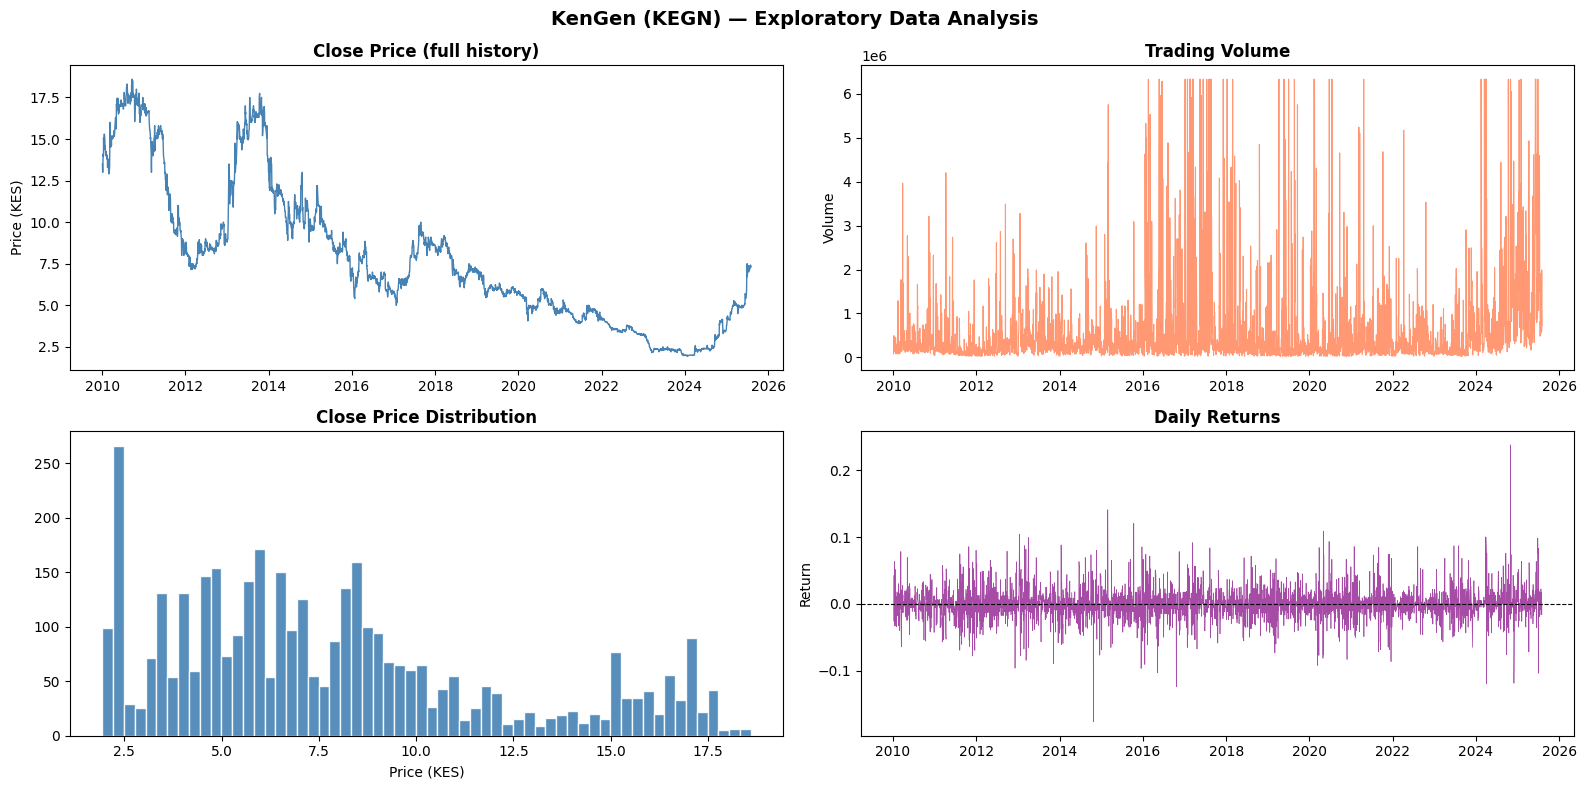

In [6]:
## Quick EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].plot(df.index, df['Close'], lw=1, color='steelblue')
axes[0, 0].set_title('Close Price (full history)', fontweight='bold')
axes[0, 0].set_ylabel('Price (KES)')

axes[0, 1].plot(df.index, df['Volume'], lw=0.8, color='coral', alpha=0.8)
axes[0, 1].set_title('Trading Volume', fontweight='bold')
axes[0, 1].set_ylabel('Volume')

axes[1, 0].hist(df['Close'], bins=60, color='steelblue', edgecolor='white', alpha=0.9)
axes[1, 0].set_title('Close Price Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Price (KES)')

axes[1, 1].plot(df['Close'].pct_change().dropna(), lw=0.5, color='purple', alpha=0.7)
axes[1, 1].axhline(0, color='black', lw=0.8, ls='--')
axes[1, 1].set_title('Daily Returns', fontweight='bold')
axes[1, 1].set_ylabel('Return')

plt.suptitle(f'{stock_name} — Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()


---
## Section 3: ARIMA Modelling

### What is ARIMA?
ARIMA (AutoRegressive Integrated Moving Average) is a classical statistical model for time series forecasting:
- **AR(p)**: models autocorrelation — uses past values to predict the future
- **I(d)**: differencing order to make the series stationary
- **MA(q)**: models error terms — captures shock/noise structure

**Why ARIMA for stock prices?**
- Simple, interpretable, and fast to train
- Well-suited to capturing short-term linear autocorrelation
- Provides a strong statistical baseline

**Limitations**: ARIMA assumes linearity and stationarity; it cannot capture long-term non-linear dependencies, which deep learning models address.

### Splitting Strategy
We reserve the last $n$ days as the out-of-sample test set. For ARIMA the test set is short as the model performs poorly with longer time horizons.


In [7]:
## Set aside n days as the testing period
forecast_horizon = 15

arima_series = df['Close'].copy()
arima_train  = arima_series.iloc[:-forecast_horizon]
arima_test   = arima_series.iloc[-forecast_horizon:]

print(f"ARIMA train: {len(arima_train)} rows  "
      f"({arima_train.index[0].date()} → {arima_train.index[-1].date()})")
print(f"ARIMA test : {len(arima_test)} rows   "
      f"({arima_test.index[0].date()} → {arima_test.index[-1].date()})")


ARIMA train: 3866 rows  (2010-01-04 → 2025-07-11)
ARIMA test : 15 rows   (2025-07-14 → 2025-08-01)


In [8]:
## Perform the ADF Test (on raw close price)
def adf_report(series, label='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    print(f"{label:30s} | ADF = {stat:8.4f} | p = {pval:.4f} | "
          f"{'STATIONARY' if pval < 0.05 else 'NON-STATIONARY'}")
    return pval < 0.05

is_stationary = adf_report(arima_train, 'ARIMA train (raw Close)')


ARIMA train (raw Close)        | ADF =  -1.8112 | p = 0.3749 | NON-STATIONARY


In [9]:
## Stationarity testing on differenced price
if not is_stationary:
    adf_report(arima_train.diff().dropna(), 'ARIMA train (1st difference)')
    d_order = 1
else:
    d_order = 0
print(f"\nDifferencing order d = {d_order}")


ARIMA train (1st difference)   | ADF = -18.6573 | p = 0.0000 | STATIONARY

Differencing order d = 1


### ARIMA(p,d,q) Parameter Selection via `pmdarima`
We use `pm.auto_arima` which performs an information-criterion-guided search (AIC) over candidate orders to find the optimal (p, d, q).


In [10]:
## pmdarima Grid Search
t0 = time.time() # to record time taken

arima_model = pm.auto_arima(
    arima_train,
    start_p=0, max_p=8,
    start_q=0, max_q=8,
    d=1, # Integration order is 1 as it requires 1 differencing order to make the data stationary as per the above ADF test
    seasonal=False, 
    information_criterion='aic', # The lower the AIC the better
    stepwise= True, # We find a model with lower AIC with stepwise=False
    suppress_warnings=True,
    error_action='ignore',
    trace=True) # prints search progress


print(f"\nTime taken {time.time()-t0:.1f}s")
print(f"\nSelected order: ARIMA{arima_model.order}")
print(f"AIC: {arima_model.aic():.2f}")

print(arima_model.summary())

Performing stepwise search to minimize aic


 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1428.520, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1427.761, Time=0.24 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1427.811, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1430.251, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1424.664, Time=0.26 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.989 seconds

Time taken 1.0s

Selected order: ARIMA(0, 1, 0)
AIC: -1430.25
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3866
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 716.126
Date:                Tue, 24 Mar 2026   AIC                          -1430.251
Time:                        15:56:21   BIC                          -1423.991
Sample:                             0   HQIC                         -1428.028
                               - 3866              

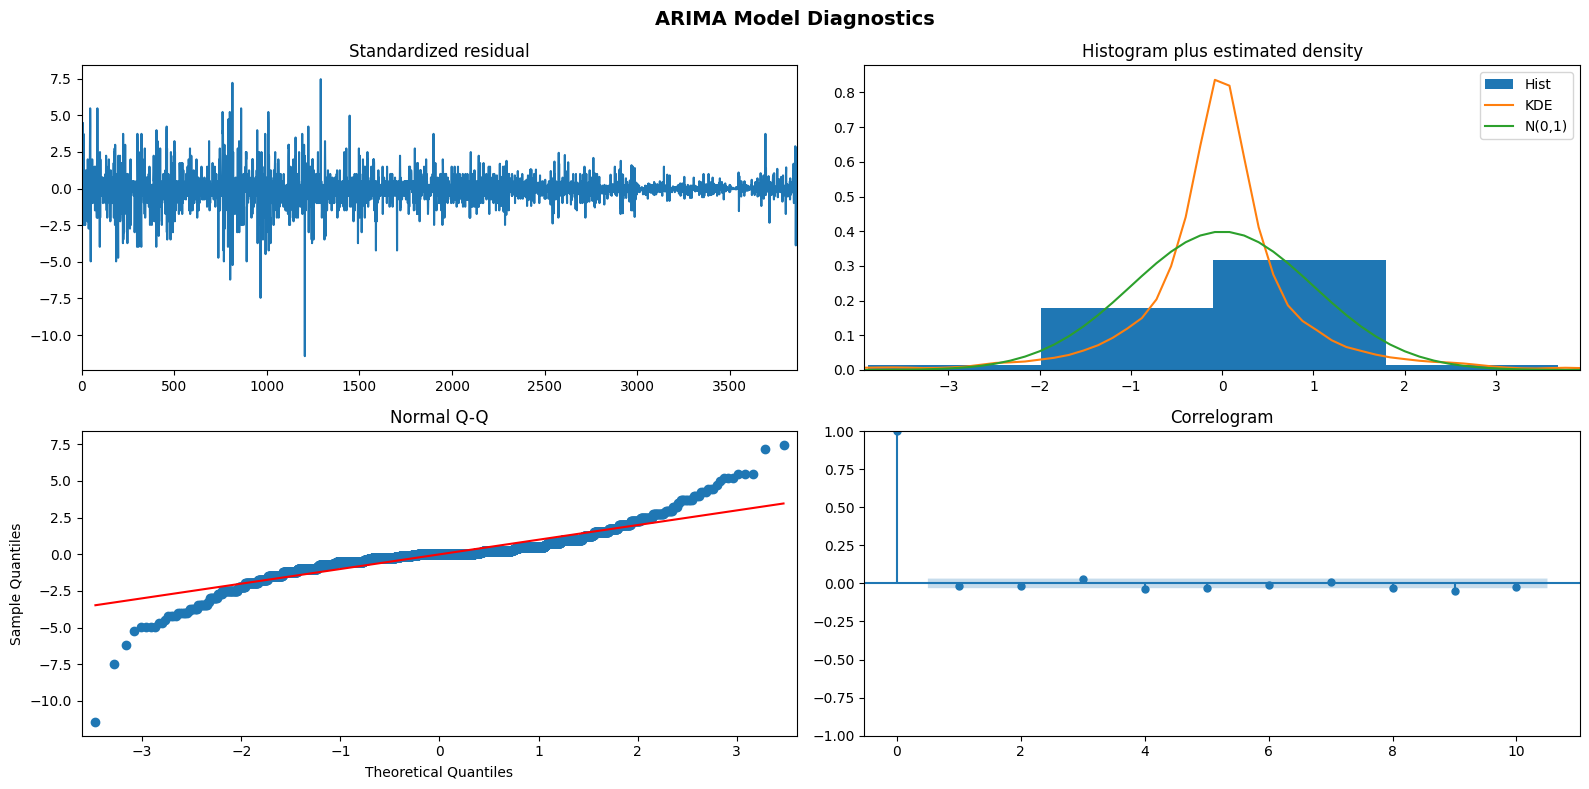

In [11]:
## Model diagnostics
arima_model.plot_diagnostics(figsize=(16, 8))
plt.suptitle('ARIMA Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()


### ARIMA Prediction
We use a **30-day out-of-sample (OOS) multi-step forecast**: fitted once on the full training series and predicts all 30 test days in a single call with a 95% confidence interval.

This directly matches the test set (last n days), ensuring alignment with all other models.


In [12]:
## n-day OOS multi-step forecast
arima_forecast, conf_int = arima_model.predict(
    n_periods=forecast_horizon,
    return_conf_int=True,
    alpha=0.05)

# Keep as arrays for downstream use
arima_test_preds = np.array(arima_forecast)

# ## Validation-window ARIMA walk-forward predictions
# # For the ensemble meta-learner we need ARIMA predictions on the validation window.
# # We re-fit ARIMA up to the start of the validation window and walk forward.
# arima_val_preds_list = []
# val_start_idx = len(arima_train) - forecast_horizon  # approximate val window

# print("Building ARIMA walk-forward predictions for validation window...")
# # Use last N days before test as the val target
# val_close = arima_series.iloc[-(forecast_horizon * 2):-forecast_horizon]
# train_for_val = arima_series.iloc[:-(forecast_horizon * 2)]

# arima_val_model = pm.auto_arima(
#     train_for_val,
#     order=arima_model.order,
#     suppress_warnings=True,
#     error_action='ignore')
# arima_val_preds = np.array(arima_val_model.predict(n_periods=forecast_horizon))

# print(f"ARIMA val preds shape  : {arima_val_preds.shape}")
print(f"ARIMA test preds shape : {arima_test_preds.shape}")
print(f"ARIMA test predictions (first 5): {arima_test_preds[:5]}")


ARIMA test preds shape : (15,)
ARIMA test predictions (first 5): [7.02 7.02 7.02 7.02 7.02]


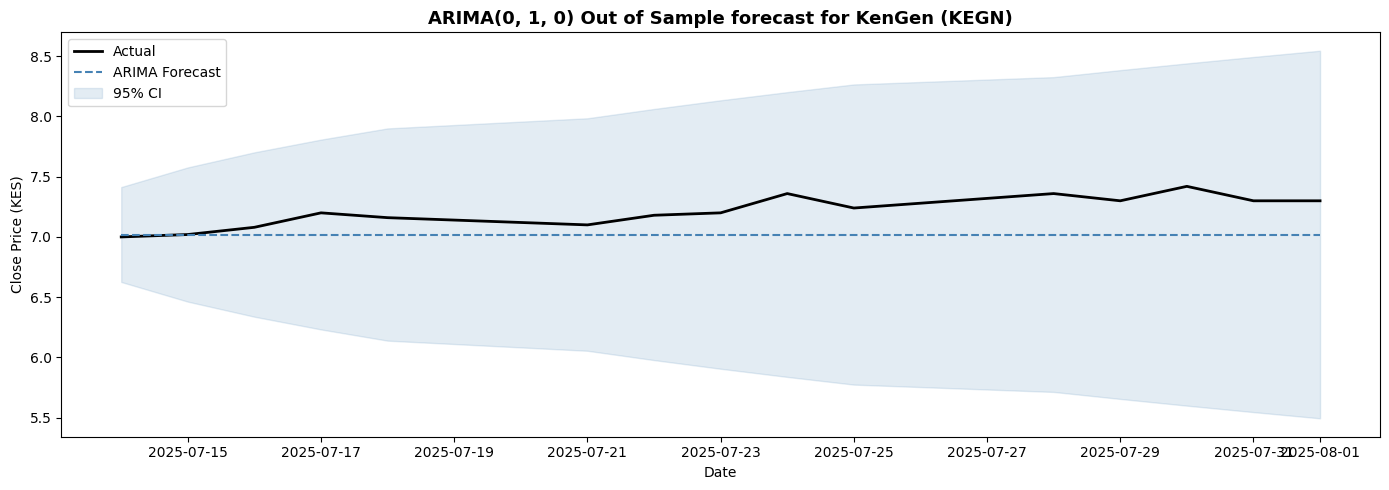

In [13]:
## Plot ARIMA Forecast vs Actual
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(arima_test.index, arima_test.values, label='Actual', color='black', lw=2)
ax.plot(arima_test.index, arima_test_preds,  label='ARIMA Forecast', color='steelblue', lw=1.5, ls='--')
ax.fill_between(arima_test.index, conf_int[:, 0], conf_int[:, 1],
                alpha=0.15, color='steelblue', label='95% CI')

ax.set_title(f'ARIMA{arima_model.order} Out of Sample forecast for {stock_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (KES)')
ax.legend()
plt.tight_layout()


---
## Section 4: Feature Engineering

We construct a rich feature matrix in three layers:
1. **Technical Indicators**: momentum, trend, volatility, and volume oscillators (via `pandas_ta`)
2. **Custom Features**: typical price, true range
3. **Lagged Close Prices**: 15 lags of the target variable capturing autoregressive structure

### Target Variable
`close_t1`: the next-day closing price (shift by -1), making this a **supervised one-step-ahead regression** problem.


In [14]:
raw_df = df.copy()

## Technical Indicators using pandas_ta
def add_all_indicators(raw_df):
    ## Trend / Moving Averages
    for p in [5, 10, 15, 20]:
        raw_df[f'SMA_{p}']  = ta.sma(raw_df['Close'],  length=p)
        raw_df[f'EMA_{p}']  = ta.ema(raw_df['Close'],  length=p)
        raw_df[f'TRIMA_{p}'] = ta.trima(raw_df['Close'], length=p)

    for p in [10, 20, 30]:
        raw_df[f'KAMA_{p}_2_30'] = ta.kama(raw_df['Close'], length=p)

    ## MACD combinations
    for fast, slow in [(5, 10), (5, 20), (10, 20), (15, 20), (12, 26)]:
        macd = ta.macd(raw_df['Close'], fast=fast, slow=slow, signal=9)
        if macd is not None:
            for col in macd.columns:
                raw_df[col] = macd[col]

    ## ADX / DMI
    for p in [5, 10, 20]:
        adx = ta.adx(raw_df['High'], raw_df['Low'], raw_df['Close'], length=p)
        if adx is not None:
            for col in adx.columns:
                raw_df[col] = adx[col]

    ## RSI
    for p in [8, 14]:
        raw_df[f'RSI_{p}'] = ta.rsi(raw_df['Close'], length=p)

    ## ROC / Momentum
    for p in [1, 5, 10, 20]:
        raw_df[f'ROC_{p}'] = ta.roc(raw_df['Close'], length=p)
    for p in [10, 15, 20]:
        raw_df[f'MOM_{p}'] = ta.mom(raw_df['Close'], length=p)

    ## Volume / other oscillators
    eom = ta.eom(raw_df['High'], raw_df['Low'], raw_df['Close'], raw_df['Volume'])
    if eom is not None:
        raw_df['EOM_14_100000000'] = eom

    stoch = ta.stoch(raw_df['High'], raw_df['Low'], raw_df['Close'])
    if stoch is not None:
        for col in stoch.columns:
            raw_df[col] = stoch[col]

    pvo = ta.pvo(raw_df['Volume'])
    if pvo is not None:
        for col in pvo.columns:
            raw_df[col] = pvo[col]

    raw_df['OBV'] = ta.obv(raw_df['Close'], raw_df['Volume'])

    ## Bollinger Bands
    bb = ta.bbands(raw_df['Close'], length=20)
    if bb is not None:
        for col in bb.columns:
            raw_df[col] = bb[col]

    ## PPO, ATR, UO, Williams %R
    ppo = ta.ppo(raw_df['Close'])
    if ppo is not None:
        for col in ppo.columns:
            raw_df[col] = ppo[col]
    raw_df['ATRr_14']  = ta.atr(raw_df['High'], raw_df['Low'], raw_df['Close'], length=14)
    raw_df['UO_7_14_28'] = ta.uo(raw_df['High'], raw_df['Low'], raw_df['Close'])
    raw_df['WILLR_14'] = ta.willr(raw_df['High'], raw_df['Low'], raw_df['Close'], length=14)

    ## Custom
    raw_df['TRange']    = raw_df['High'] - raw_df['Low']
    # raw_df['TYPPRICE']  = (raw_df['High'] + raw_df['Low'] + raw_df['Close']) / 3

    return raw_df

raw_df = add_all_indicators(raw_df)

## Lagged close features (15 lags)
for lag in range(1, 16):
    raw_df[f'close_lag_{lag}'] = raw_df['Close'].shift(lag)

## Target: next 10 days close price
Target = 'Close_Target'
raw_df[Target] = raw_df['Close']

raw_df= raw_df.drop(columns= 'Close')

## Drop NaN rows
raw_df.dropna(inplace=True)
print(f"Final dataset shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns[:10])} ...")

raw_df.tail()

Final dataset shape: (3848, 91)
Columns: ['Open', 'High', 'Low', 'Volume', 'SMA_5', 'EMA_5', 'TRIMA_5', 'SMA_10', 'EMA_10', 'TRIMA_10'] ...


,Open,High,Low,Volume,SMA_5,EMA_5,TRIMA_5,SMA_10,EMA_10,TRIMA_10,...,close_lag_7,close_lag_8,close_lag_9,close_lag_10,close_lag_11,close_lag_12,close_lag_13,close_lag_14,close_lag_15,Close_Target
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-28,7.24,7.40,7.20,1111500.0,7.268,7.274073,7.277778,7.190,7.208801,7.169444,...,7.20,7.08,7.02,7.00,7.02,7.12,7.26,7.38,7.40,7.36
2025-07-29,7.36,7.40,7.28,842400.0,7.292,7.282716,7.295556,7.218,7.225383,7.199444,...,7.16,7.20,7.08,7.02,7.00,7.02,7.12,7.26,7.38,7.30
2025-07-30,7.40,7.46,7.30,592200.0,7.336,7.328477,7.326667,7.252,7.260768,7.231111,...,7.10,7.16,7.20,7.08,7.02,7.00,7.02,7.12,7.26,7.42
2025-07-31,7.46,7.46,7.26,1989800.0,7.324,7.318985,7.333333,7.262,7.267901,7.260556,...,7.18,7.10,7.16,7.20,7.08,7.02,7.00,7.02,7.12,7.30
2025-08-01,7.30,7.48,7.16,724800.0,7.336,7.312656,7.346667,7.276,7.273737,7.280556,...,7.20,7.18,7.10,7.16,7.20,7.08,7.02,7.00,7.02,7.30


---
## Section 5: Data Preprocessing

### Data Splitting
We apply an 70/15/15 chronological split
- **Train** (70%): used to fit all models
- **Validation** (15%): used for hyperparameter tuning and meta-learner training
- **Test** (15%): held out; never touched during training or tuning

The test set must contain at least `WINDOW_SIZE` rows to form meaningful sliding windows.

In [15]:
n = len(raw_df)
WINDOW_SIZE = 60
# WINDOW_SIZE = WINDOW_SIZE + 50

test_size  = max(WINDOW_SIZE, int(n * 0.15))
val_size   = max(WINDOW_SIZE, int(n * 0.15))
train_size = n - val_size - test_size

train_end = train_size
val_end   = train_size + val_size

train_df = raw_df.iloc[:train_end].copy()
val_df   = raw_df.iloc[train_end:val_end].copy()
test_df  = raw_df.iloc[val_end:].copy()

print(f"Train : Shape: {train_df.shape} | {len(train_df)} rows  ({train_df.index[0].date()} → {train_df.index[-1].date()})")
print(f"Val   : Shape: {val_df.shape} | {len(val_df)} rows  ({val_df.index[0].date()}   → {val_df.index[-1].date()})")
print(f"Test  : Shape: {test_df.shape} | {len(test_df)} rows  ({test_df.index[0].date()}   → {test_df.index[-1].date()})")


Train : Shape: (2694, 91) | 2694 rows  (2010-02-18 → 2020-12-03)
Val   : Shape: (577, 91) | 577 rows  (2020-12-04   → 2023-03-29)
Test  : Shape: (577, 91) | 577 rows  (2023-03-30   → 2025-08-01)


In [16]:
## Data Transformation: MinMaxScaling
feature_cols = [c for c in raw_df.columns if c != Target]
print(f"Feature columns ({len(feature_cols)}): {feature_cols[:8]} ... (truncated)")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
n_features = len(feature_cols)

X_train_raw = train_df[feature_cols].values
y_train_raw = train_df[[Target]].values

X_val_raw   = val_df[feature_cols].values
y_val_raw   = val_df[[Target]].values

X_test_raw  = test_df[feature_cols].values
y_test_raw  = test_df[[Target]].values

# Fit only on training data and transform on val/test
X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw).ravel()

X_val   = scaler_X.transform(X_val_raw)
y_val   = scaler_y.transform(y_val_raw).ravel()

X_test  = scaler_X.transform(X_test_raw)
y_test  = scaler_y.transform(y_test_raw).ravel()

print(f"\nScaled shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")


Feature columns (90): ['Open', 'High', 'Low', 'Volume', 'SMA_5', 'EMA_5', 'TRIMA_5', 'SMA_10'] ... (truncated)

Scaled shapes: X_train=(2694, 90), X_val=(577, 90), X_test=(577, 90)


---
## Section 6: Feature Selection

We apply a two-stage feature selection process:

**Correlation Filter**: remove features with pairwise Pearson correlation ≥ 0.90 (keeping the first encountered) to eliminate redundant predictors. We compute correlations only on training data to prevent leakage.

**RFE with XGBoost**: from the remaining features, use Recursive Feature Elimination (RFE) to rank features by XGBoost importance, automatically selecting the optimal subset.


In [17]:
## Correlation filter
corr_threshold = 0.90

# Use training data (scaled) for correlation; target is unscaled for interpretability
train_df_copy        = pd.DataFrame(X_train, columns=feature_cols)
train_df_copy[Target]= y_train

corr_matrix  = train_df_copy.corr()
target_corrs = corr_matrix[Target].drop(Target).abs().sort_values(ascending=False)

print(f"Top-20 correlated features with target:")
print(target_corrs.head(20).to_string())

high_corr_features = target_corrs[target_corrs >= corr_threshold].index.tolist()
print(f"\nFeatures with correlation >= {corr_threshold}: {len(high_corr_features)}")
print(high_corr_features)

Top-20 correlated features with target:
High            0.998807
Low             0.998792
EMA_5           0.998563
close_lag_1     0.998115
SMA_5           0.997781
TRIMA_5         0.997487
EMA_10          0.996602
close_lag_2     0.996271
KAMA_10_2_30    0.995319
SMA_10          0.995010
EMA_15          0.994789
close_lag_3     0.994489
Open            0.994258
TRIMA_10        0.993619
EMA_20          0.993032
SMA_15          0.992673
close_lag_4     0.992614
TRIMA_15        0.991385
KAMA_20_2_30    0.991378
close_lag_5     0.990895

Features with correlation >= 0.9: 36
['High', 'Low', 'EMA_5', 'close_lag_1', 'SMA_5', 'TRIMA_5', 'EMA_10', 'close_lag_2', 'KAMA_10_2_30', 'SMA_10', 'EMA_15', 'close_lag_3', 'Open', 'TRIMA_10', 'EMA_20', 'SMA_15', 'close_lag_4', 'TRIMA_15', 'KAMA_20_2_30', 'close_lag_5', 'BBM_20_2.0_2.0', 'SMA_20', 'TRIMA_20', 'close_lag_6', 'close_lag_7', 'KAMA_30_2_30', 'close_lag_8', 'BBU_20_2.0_2.0', 'close_lag_9', 'close_lag_10', 'BBL_20_2.0_2.0', 'close_lag_11', 'clo

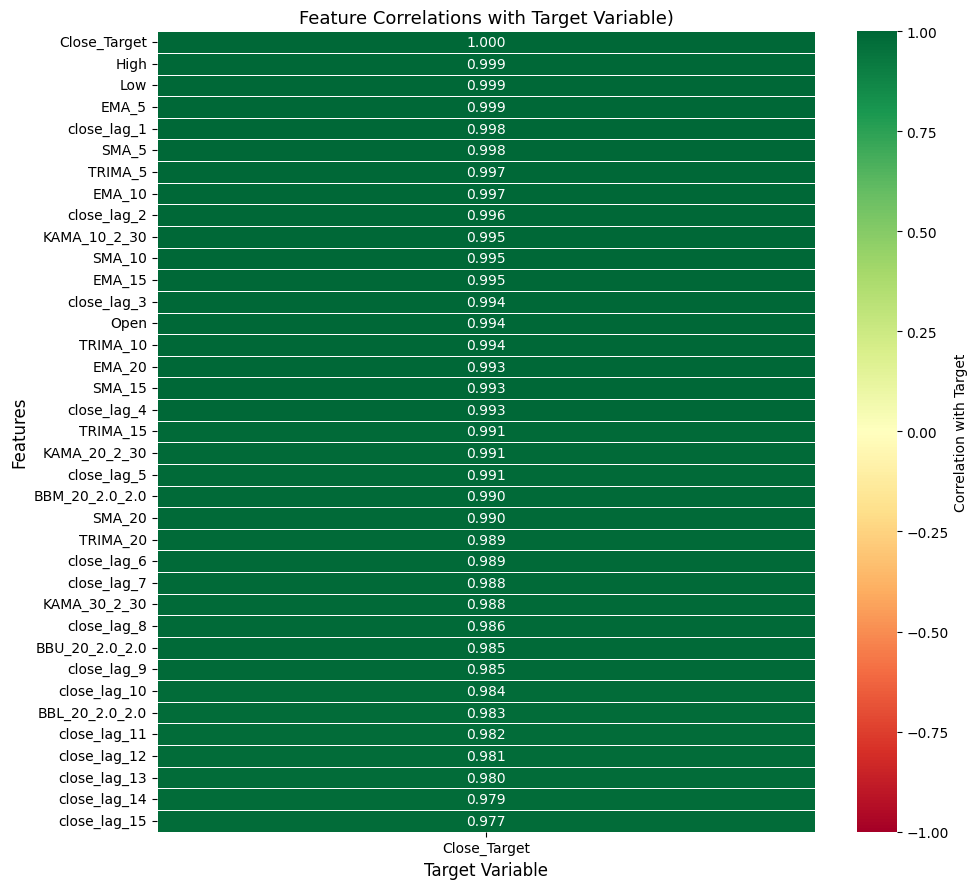

In [18]:
## Correlation Heatmap (For the selected highly correlted features)
# Get correlations with target
target_corr = train_df_copy[high_corr_features + [Target]].corr()[[Target]]

# Sort features by absolute correlation value
target_corr_sorted = target_corr.loc[target_corr[Target].abs().sort_values(ascending=False).index]

# Plotting selected features with correlation >= 0.9
fig, ax = plt.subplots(figsize=(10, len(high_corr_features) * 0.25))
sns.heatmap(target_corr_sorted, annot=True, fmt='.3f', 
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation with Target'})
ax.set_title(f'Feature Correlations with Target Variable)', 
             fontsize=13)
ax.set_ylabel('Features', fontsize=12)
ax.set_xlabel('Target Variable', fontsize=12)
plt.tight_layout()

In [19]:
device

device(type='cuda')

In [20]:
### RFE (XGBoost)
## Features that have correlation >= 0.9 proceed to the RFE stage
X_rfe = X_train[:, [feature_cols.index(f) for f in high_corr_features]]
y_rfe = y_train.copy()

## XGBoost Regressor for RFE
# XGBoost has an option to operate it on a GPU
xgb_est = XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=seed, verbosity=0,
    device="cuda", # Route computation to GPU
    tree_method="hist") # "hist" is required for GPU execution

## Create cross-validation splits
tscv = TimeSeriesSplit(n_splits=5)
# Unlike regular cross validation that randomly shuffles data, TimeSeriesSplit maintains temporal order

## Find optimal no. of features via cross-validation score.
n_candidates = range(5, len(high_corr_features) + 1)
cv_scores = []

## RFE with Cross-Validation scoring
for n_feat in n_candidates:
    rfe = RFE(estimator=xgb_est, n_features_to_select=n_feat, step=1)
    rfe.fit(X_rfe, y_rfe)
    X_rfe_sel = rfe.transform(X_rfe)
    scores = cross_val_score(xgb_est, X_rfe_sel, y_rfe,
                             cv=tscv, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())
    print(f"  n_features={n_feat:2d}  CV-MSE={-scores.mean():.6f}")
    # We use a negative MSE since sklearn assumes higher scores are better, but for MSE lower scores are better so we negate it
    # CV-MSE returns the original (unnegated) MSE

opt_n = list(n_candidates)[np.argmin(cv_scores)]
print(f"\nOptimal number of features: {opt_n}")

  n_features= 5  CV-MSE=0.000906
  n_features= 6  CV-MSE=0.000941
  n_features= 7  CV-MSE=0.000962
  n_features= 8  CV-MSE=0.000993
  n_features= 9  CV-MSE=0.001018
  n_features=10  CV-MSE=0.001030
  n_features=11  CV-MSE=0.001019
  n_features=12  CV-MSE=0.001064
  n_features=13  CV-MSE=0.001045
  n_features=14  CV-MSE=0.001060
  n_features=15  CV-MSE=0.001084
  n_features=16  CV-MSE=0.001095
  n_features=17  CV-MSE=0.001046
  n_features=18  CV-MSE=0.001025
  n_features=19  CV-MSE=0.001082
  n_features=20  CV-MSE=0.001101
  n_features=21  CV-MSE=0.001071
  n_features=22  CV-MSE=0.001028
  n_features=23  CV-MSE=0.001045
  n_features=24  CV-MSE=0.001038
  n_features=25  CV-MSE=0.001093
  n_features=26  CV-MSE=0.001097
  n_features=27  CV-MSE=0.001137
  n_features=28  CV-MSE=0.001066
  n_features=29  CV-MSE=0.001062
  n_features=30  CV-MSE=0.001078
  n_features=31  CV-MSE=0.001095
  n_features=32  CV-MSE=0.001072
  n_features=33  CV-MSE=0.001179
  n_features=34  CV-MSE=0.001130
  n_featur

Selected features (5):
['High', 'Low', 'EMA_5', 'close_lag_1', 'Open']

Importance threshold : 0.02
Features kept (4)  : ['close_lag_1', 'EMA_5', 'Low', 'High']
Features dropped (1) : ['Open']

Final feature matrix shapes:
  X_train_sel : (2694, 4)
  X_val_sel   : (577, 4)
  X_test_sel  : (577, 4)


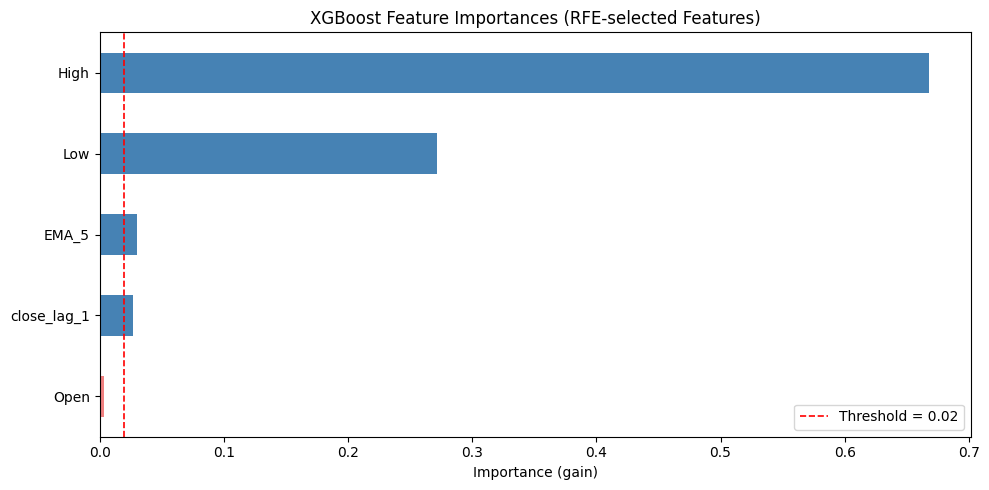

In [21]:
## Final RFE fit with optimal n
rfe_final = RFE(estimator=xgb_est, n_features_to_select=opt_n, step=1)
rfe_final.fit(X_rfe, y_rfe)

## Selected features from the high correlation analysis
selected_from_hc = [high_corr_features[i]
                    for i, s in enumerate(rfe_final.support_) if s]
print(f"Selected features ({len(selected_from_hc)}):")
print(selected_from_hc)

## Feature importance plot
xgb_est.fit(X_rfe[:, rfe_final.support_], y_rfe,
            eval_set=[(X_rfe[:, rfe_final.support_], y_rfe)],
            verbose=False)

importances = pd.Series(xgb_est.feature_importances_,
                        index=selected_from_hc).sort_values(ascending=True)

## Importance threshold filter
# We would like to drop some features below a specified threshold score
importance_threshold = 0.02   # <── set your cutoff here

kept_features   = importances[importances >= importance_threshold].index.tolist()
dropped_features = importances[importances <  importance_threshold].index.tolist()

print(f"\nImportance threshold : {importance_threshold}")
print(f"Features kept ({len(kept_features)})  : {kept_features}")
print(f"Features dropped ({len(dropped_features)}) : {dropped_features}")

## Feature importance plot (colour-coded by keep/drop)
colors = ['steelblue' if f in kept_features else 'lightcoral'
          for f in importances.index]

fig, ax = plt.subplots(figsize=(10, max(5, len(importances) * 0.4)))
importances.plot.barh(ax=ax, color=colors)
ax.axvline(importance_threshold, color='red', linestyle='--', linewidth=1.2, 
           label= f'Threshold = {importance_threshold}')
ax.set_title('XGBoost Feature Importances (RFE-selected Features)')
ax.set_xlabel('Importance (gain)')
ax.legend()
plt.tight_layout()

## Update X arrays to threshold-surviving features
sel_indices = [feature_cols.index(f) for f in kept_features]
X_train_sel = X_train[:, sel_indices]
X_val_sel   = X_val[:,   sel_indices]
X_test_sel  = X_test[:,  sel_indices]
n_features  = len(kept_features)

## Update the active feature list for downstream stages
selected_from_hc = kept_features

print(f"\nFinal feature matrix shapes:")
print(f"  X_train_sel : {X_train_sel.shape}")
print(f"  X_val_sel   : {X_val_sel.shape}")
print(f"  X_test_sel  : {X_test_sel.shape}")


---
## Section 7: Sliding Window Construction

### The Sliding Window Approach
We transform the raw time series into supervised learning samples by moving a fixed-length window of size `W=30` one step at a time across the series. Each window provides a sequence of `(W, F)` feature vectors, and the target is the Close price at the final day of that window.

This is the standard approach for sequence models (LSTM, xLSTM, Transformer) on financial time series.


In [22]:
def create_windows(X: np.ndarray, y: np.ndarray, WINDOW_SIZE: int = WINDOW_SIZE):
    """
    Convert (N, F) feature matrix and (N,) target vector into
    sliding-window tensors of shape (samples, WINDOW_SIZE, F).

    Target is taken at the LAST row of each window (i + WINDOW_SIZE - 1),
    so the model sees features [i ... i+WINDOW_SIZE-1] and predicts the
    target value at the final day of that window.

    Returns
    -------
    X_win : np.ndarray  shape (S, WINDOW_SIZE, F)
    y_win : np.ndarray  shape (S,)
    """
    assert WINDOW_SIZE > 0, "WINDOW_SIZE must be a positive integer"
    assert len(X) > WINDOW_SIZE, (
        f"Not enough rows ({len(X)}) to form any window of size {WINDOW_SIZE}")
    Xs, ys = [], []
    for i in range(len(X) - WINDOW_SIZE):
        Xs.append(X[i: i + WINDOW_SIZE])
        ys.append(y[i + WINDOW_SIZE - 1])
    return np.array(Xs), np.array(ys)


X_win_train, y_win_train = create_windows(X_train_sel, y_train, WINDOW_SIZE)
X_win_val,   y_win_val   = create_windows(X_val_sel,   y_val,   WINDOW_SIZE)
X_win_test,  y_win_test  = create_windows(X_test_sel,  y_test,  WINDOW_SIZE)

# Date indices corresponding to the last day of each window
val_win_dates  = val_df.index[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_win_val)]
test_win_dates = test_df.index[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_win_test)]

print(f"Window shapes:")
print(f"  X_win_train : {X_win_train.shape}  (samples, timesteps, features)")
print(f"  X_win_val   : {X_win_val.shape}")
print(f"  X_win_test  : {X_win_test.shape}")
print(f"\nVal  window dates : {val_win_dates[0].date()}  →  {val_win_dates[-1].date()}")
print(f"Test window dates : {test_win_dates[0].date()} →  {test_win_dates[-1].date()}")

Window shapes:
  X_win_train : (2634, 60, 4)  (samples, timesteps, features)
  X_win_val   : (517, 60, 4)
  X_win_test  : (517, 60, 4)

Val  window dates : 2021-03-01  →  2023-03-28
Test window dates : 2023-06-29 →  2025-07-31


We define utility functions that we will use throughout the rest of the notebook.

In [23]:
## DataLoader function for converting data into tensors and easy loading into PyTorch models
def make_data_loader(X_np, y_np, batch_size, shuffle=False):
    """Wraps numpy arrays into a PyTorch DataLoader."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)
    ds  = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

## Generic predict function
def model_predict(model, X_data, batch_size=256):
    """Run inference on X_data and return numpy predictions."""
    model.eval()
    preds_all = []
    loader = make_data_loader(X_data, np.zeros(len(X_data)), batch_size=batch_size)
    with torch.inference_mode():
        for Xb, _ in loader:
            out = model(Xb.to(device)).cpu().numpy().ravel()
            preds_all.extend(out)
    return np.array(preds_all)

## Generic inverse transform
def inv_transform(preds_scaled):
    """Inverse MinMax scale from [0,1] back to raw price."""
    return scaler_y.inverse_transform(
        preds_scaled.reshape(-1, 1)).ravel()

## Checkpoint save/load utilities
def save_checkpoint(state, filepath):
    """Save training checkpoint to filepath."""
    torch.save(state, filepath)

def load_checkpoint(filepath, model, optimizer=None):
    """Load checkpoint; returns epoch and best val loss."""
    ckpt = torch.load(filepath, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    if optimizer and 'optimizer_state' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state'])
    return ckpt.get('epoch', 0), ckpt.get('val_loss', float('inf'))


---
## Section 8: LSTM Model (PyTorch)

### What is an LSTM?
Long Short-Term Memory (Hochreiter & Schmidhuber, 1997) is a gated recurrent neural network designed to learn long-range dependencies:

| Gate | Purpose |
|---|---|
| **Forget gate** $f_t$ | Decides what to erase from cell state |
| **Input gate** $i_t$ | Decides what new info to write |
| **Output gate** $o_t$ | Decides what to expose as hidden state |

The cell state $C_t$ acts as a "conveyor belt" that carries information across many time steps without vanishing gradients.

### Why LSTM for Stock Prices?
- Naturally handles sequential data of variable-length dependencies
- Gating prevents vanishing gradients (unlike vanilla RNNs)
- Proven strong performance on financial time series

### Architecture
- Input: `(batch, seq_len=30, n_features)`
- Stacked LSTM layers with inter-layer dropout
- Fully connected head: `hidden → fc_units → 1` with ReLU


In [24]:
class StockLSTM(nn.Module):
    """
    Multi-layer LSTM for financial time series regression.

    Parameters
    ----------
    input_size  : number of features per time step
    hidden_size : LSTM hidden units
    num_layers  : number of stacked LSTM layers
    dropout     : dropout probability between LSTM layers
    fc_units    : units in the intermediate fully-connected layer
    """
    def __init__(self, input_size: int,
                 hidden_size: int = 128,
                 num_layers:  int = 2,
                 dropout:     float = 0.3,
                 fc_units:    int = 64):
        super().__init__()
        # 2 LSTM layers with 128 units per layer
        self.lstm    = nn.LSTM(input_size=input_size,
                               hidden_size=hidden_size,
                               num_layers=num_layers,
                               dropout=dropout if num_layers > 1 else 0.0, #Droput is 0.3 if we have more than 1 layer else no dropout at all
                               batch_first= True) # Ensures the input tensor shape: (batch, seq_len, features)
        
        # After the LSTM layer we have a 2 fully connected (Dense) layers
        self.dropout = nn.Dropout(dropout) # Regularizer on the LSTM's output
        self.fc1     = nn.Linear(hidden_size, fc_units) # Takes 128 outputs from LSTM, produces 68 outputs
        self.relu    = nn.ReLU() # Activation function for non-linearity
        self.fc2     = nn.Linear(fc_units, 1) # Takes 64 outputs and produces 1 single output 

    # Forward pass
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        # LSTM returns two things: out and a tuple containing (hidden_state, cell_state)
        # out contains (batch, seq_len, hidden_size) which is what we need
        # out is the entire sequence of hidden states from the LSTM layer we only need the final time step from it
        out= self.dropout(out[:, -1, :]) # take last time step
        out= self.relu(self.fc1(out)) # Activation function for non-Linearity
        return self.fc2(out) # (batch, 1)


# Quick sanity check
_demo= StockLSTM(input_size=n_features).to(device)
_x= torch.randn(4, WINDOW_SIZE, n_features).to(device)
 # creates a random batch of 4 sequences, each WINDOW_SIZE time steps long, with n_features features per step
print(f"Demo output shape: {_demo(_x).shape}")
print(f"Model parameters: {sum(p.numel() for p in _demo.parameters()):,}")
print(_demo)


Demo output shape: torch.Size([4, 1])
Model parameters: 209,025
StockLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


### Hyperparameter Tuning (LSTM)
Rather than perform a random search, we apply Bayesian Optimization (BO) to find the best hyperparameters for the LSTM model. We use the `optuna` library to perform the hyperparameter tuning. Because of how dynamically BO updates its parameters, we are able to use a much larger hyperparameter search space than would be possible with a random search with lesser number of trials.

Key hyperparameters tuned:
| Parameter | Search Space |
|---|---|
| `hidden_size` | 32 – 400 (step 16) |
| `num_layers` | 1 – 3 |
| `dropout` | 0.1, 0.2, 0.3 |
| `lr` | 1e-1, 1e-2, 1e-3, 5e-4 |
| `batch_size` | 16, 32, 64, 128 |
| `fc_units` | 16 – 128 (step 16) |


In [25]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

lstm_trials= 30
lstm_epochs= 40
lstm_startup_trials= 7

## Budget
lstm_total_budget_seconds = 2700  # 45 minutes total
lstm_max_trial_seconds    = 300   # 5 minutes per trial

## Early Stopping
ES_PATIENCE  = 7    # epochs to wait after last improvement
ES_MIN_DELTA = 1e-5 # minimum improvement to count as progress


## Objective function
def lstm_objective(trial: optuna.Trial) -> float:
    """
    Define the search space, build & train a StockLSTM with sampled params,
    report intermediate val losses for pruning, and return the best val loss.

    Key differences from the random search:
      - suggest_int / suggest_float / suggest_categorical replace manual grids.
        Optuna uses these type hints to build the correct internal representation
        (integer, continuous log-uniform, categorical).
      - trial.report() + trial.should_prune() hooks in the epoch loop allow
        MedianPruner to kill bad trials before they waste their full 60 epochs.
    """

    ## Hyperparameters
    # suggest_int(name, low, high, step=1) samples an integer in [low, high] inclusive.
    hidden_size= trial.suggest_int("hidden_size", 32, 256, step=16)
    num_layers = trial.suggest_int("num_layers",  1,  6)
    fc_units= trial.suggest_int("fc_units", 32, 256, step=32)

    # suggest_float(name, low, high, log=True) does the same
    dropout= trial.suggest_float("dropout", 0.1, 0.5)
    lr= trial.suggest_float("lr", 0.0001, 0.01, log=True)
     # The learning rate range traverses multiple orders of magnitude (from 10^-8 to 10^-1)
     # It therefore must be in a logarithmic range
     

    # suggest_categorical(name, choices): Optuna treats each as a separate category.
    batch_size  = trial.suggest_categorical("batch_size", [32, 64, 128])

    ## Model, optimiser, data loader 
    model_t = StockLSTM(input_size= n_features, 
                        hidden_size= hidden_size, 
                        num_layers= num_layers, 
                        dropout= dropout, 
                        fc_units= fc_units).to(device)

    opt_t     = torch.optim.Adam(model_t.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_ld  = make_data_loader(X_win_train, y_win_train, batch_size, shuffle=True)

    ## Training loop with Optuna pruning hooks + early stopping
    best_val_loss    = float("inf")
    es_counter       = 0          # epochs since last improvement
    es_stopped_epoch = None
    trial_start      = time.time()

    for ep in range(lstm_epochs):

        # — train one epoch —
        model_t.train()
        for Xb, yb in train_ld:
            opt_t.zero_grad()
            loss = criterion(model_t(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_t.step()

        # — validate —
        val_preds = model_predict(model_t, X_win_val)
        val_loss  = mean_squared_error(y_win_val, val_preds)

        # Early stopping check (before reporting to pruner)
        # Runs first — if the trial has plateaued within itself,
        # there's no point feeding a stale val_loss to the MedianPruner.
        if val_loss < (best_val_loss - ES_MIN_DELTA):
            best_val_loss = val_loss
            es_counter    = 0
        else:
            es_counter += 1
            if es_counter >= ES_PATIENCE:
                es_stopped_epoch = ep
                break   # exit epoch loop, return best_val_loss seen so far

        # — report to pruner & check —
        trial.report(val_loss, step=ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
         # TrialPruned() is function from the optuna MedianPruner()
         # MedianPruner() kills underperforming trials mid-training rather than letting them run to completion, saving time and compute resources

        # — wall-time cap per trial —
        if time.time() - trial_start > lstm_max_trial_seconds:
            raise optuna.exceptions.TrialPruned()

    return best_val_loss


## Create the Optuna study 
# A "study" is the container for all trials, the surrogate model state, and the results database.
study = optuna.create_study(direction = "minimize",
    sampler= TPESampler(seed=seed, n_startup_trials= lstm_startup_trials),
    pruner= MedianPruner(n_startup_trials= lstm_startup_trials, 
                         n_warmup_steps= lstm_startup_trials),
    study_name= "LSTM_BayesOpt")

## Callback: live trial logging 
# Optuna also supports callbacks during optimisation as an alternative to post-hoc printing — pass it via study.optimize(callbacks=[log_trial])
def log_trial(study: optuna.Study, trial: optuna.trial.FrozenTrial):
    if trial.state == optuna.trial.TrialState.COMPLETE:
        print(
            f"Trial {trial.number+1:3d}"
            f"val_loss={trial.value:.6f}"
            f"hidden={trial.params['hidden_size']}"
            f"layers={trial.params['num_layers']}"
            f"lr={trial.params['lr']:.5f}"
            f"bs={trial.params['batch_size']}")
    elif trial.state == optuna.trial.TrialState.PRUNED:
        print(f"  Trial {trial.number+1:3d}  PRUNED at epoch ~"
              f"{trial.last_step}")

## Run the optimisation
# Many trials can be run here due to how BO works and also pruning
print(f"Bayesian Optimisation: up to {lstm_trials} trials (with early pruning)")
print(f"Sampler: TPE  |  Pruner: MedianPruner  |  Direction: minimise val MSE\n")
study.optimize(lstm_objective,
               n_trials= lstm_trials,
               timeout= lstm_total_budget_seconds,  # 45-minute wall-time budget
               show_progress_bar= True, 
               callbacks= [log_trial])

## Extract best hyperparameters
best_trial  = study.best_trial
lstm_best_params = study.best_params # dict: {param_name: value}
lstm_best_params["val_loss"] = study.best_value

print(f"Best hyperparameters found (trial #{best_trial.number + 1}):")
for k, v in lstm_best_params.items():
    print(f"  {k:15s}: {v}")


## Results DataFrame 
# study.trials_dataframe() mirrors the original results_df_hp, with extra
# columns for trial state (COMPLETE / PRUNED) and datetime info.
results_df_hp = (study.trials_dataframe(attrs=("number", "value", "params", "state"))
                .rename(columns={"value": "val_loss"})
                .sort_values("val_loss"))

print(f"\nAll completed trials (sorted by val_loss):")
completed = results_df_hp[results_df_hp["state"] == "COMPLETE"]
print(completed.head(10).to_string(index=False))


## Optional: importance analysis 
# Optuna can estimate which hyperparameters had the most impact on the objective. 
# This uses fANOVA (functional ANOVA) under the hood.
# Requires: pip install optuna[optional]  (for scikit-learn dependency)
try:
    importance = optuna.importance.get_param_importances(study)
    print(f"\nHyperparameter importances:")
    for param, imp in importance.items():
        bar = "█" * int(imp * 30)
        print(f"  {param:15s}: {bar:<30s} {imp:.3f}")
except Exception:
    pass   # fANOVA needs ≥ 4 completed trials with varied params

Bayesian Optimisation: up to 30 trials (with early pruning)
Sampler: TPE  |  Pruner: MedianPruner  |  Direction: minimise val MSE



  0%|          | 0/30 [00:00<?, ?it/s]

Trial   1val_loss=0.000926hidden=112layers=6lr=0.00021bs=128
Trial   2val_loss=0.002544hidden=176layers=5lr=0.00462bs=32
Trial   3val_loss=0.000217hidden=96layers=4lr=0.00167bs=128
Trial   4val_loss=0.001206hidden=128layers=5lr=0.00153bs=64
Trial   5val_loss=0.002291hidden=32layers=6lr=0.00041bs=64


Trial   6val_loss=0.001043hidden=48layers=3lr=0.00033bs=32
Trial   7val_loss=0.000128hidden=160layers=2lr=0.00757bs=128
Trial   8val_loss=0.000596hidden=256layers=1lr=0.00928bs=128
Trial   9val_loss=0.000363hidden=192layers=1lr=0.00426bs=128
Trial  10val_loss=0.000385hidden=240layers=2lr=0.00071bs=128
  Trial  11  PRUNED at epoch ~7
Trial  12val_loss=0.001009hidden=80layers=4lr=0.00200bs=128
Trial  13val_loss=0.000196hidden=96layers=2lr=0.00251bs=128
Trial  14val_loss=0.000325hidden=144layers=2lr=0.00364bs=128
Trial  15val_loss=0.000509hidden=64layers=2lr=0.00374bs=128
  Trial  16  PRUNED at epoch ~7
  Trial  17  PRUNED at epoch ~7
Trial  18val_loss=0.000455hidden=144layers=3lr=0.00227bs=128
Trial  19val_loss=0.000353hidden=96layers=2lr=0.00122bs=64
Trial  20val_loss=0.000333hidden=224layers=1lr=0.00068bs=32
Trial  21val_loss=0.000290hidden=160layers=3lr=0.00267bs=128
Trial  22val_loss=0.000572hidden=96layers=4lr=0.00081bs=128
Trial  23val_loss=0.000244hidden=112layers=4lr=0.00584bs=12

### Full LSTM Training with Best Hyperparameters

We train the LSTM for up to 150 epochs with:
- **Early stopping** (patience=15): halt if validation loss does not improve
- **ReduceLROnPlateau** (patience=7): halve the learning rate on plateau
- **Checkpointing**: save the best model weights to disk every time validation loss improves


In [26]:
## Full LSTM Training
max_epochs = 150
patience   = 15
lr_patience= 7
lstm_ckpt  = os.path.join(CKPT_DIR, 'lstm_best.pt')

lstm_model = StockLSTM(
    input_size  = n_features,
    hidden_size = int(lstm_best_params['hidden_size']),
    num_layers  = int(lstm_best_params['num_layers']),
    dropout     = float(lstm_best_params['dropout']),
    fc_units    = int(lstm_best_params['fc_units'])
).to(device)

optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=float(lstm_best_params['lr']))
scheduler  = ReduceLROnPlateau(optimizer, 'min', patience=lr_patience,
                               factor=0.5)
criterion  = nn.MSELoss()

train_ld   = make_data_loader(X_win_train, y_win_train,
                               int(lstm_best_params['batch_size']), shuffle=True)

train_losses, val_losses_hist = [], []
best_val_loss = float('inf')
no_improve    = 0
CKPT_FREQ     = 10   # Save a checkpoint every 10 epochs regardless of improvement

print(f"Training LSTM  | hidden={int(lstm_best_params['hidden_size'])}  "
      f"layers={int(lstm_best_params['num_layers'])}  dropout={lstm_best_params['dropout']}  "
      f"lr={lstm_best_params['lr']}  bs={int(lstm_best_params['batch_size'])}")
print(f"Max epochs={max_epochs}  patience={patience}")

for epoch in range(1, max_epochs + 1):
    lstm_model.train()
    ep_loss = 0.0
    for Xb, yb in train_ld:
        optimizer.zero_grad()
        loss = criterion(lstm_model(Xb.to(device)), yb.to(device))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item() * len(Xb)
    ep_loss /= len(X_win_train)

    val_preds = model_predict(lstm_model, X_win_val)
    val_loss  = mean_squared_error(y_win_val, val_preds)
    scheduler.step(val_loss)

    train_losses.append(ep_loss)
    val_losses_hist.append(val_loss)

    # Best model checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        save_checkpoint({
            'model_state'    : lstm_model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'epoch'          : epoch,
            'val_loss'       : best_val_loss,
            'hyperparams'    : lstm_best_params,}, lstm_ckpt)
    else:
        no_improve += 1

    # Periodic checkpoint every CKPT_FREQ epochs
    if epoch % CKPT_FREQ == 0:
        periodic_path = os.path.join(CKPT_DIR, f'lstm_epoch_{epoch}.pt')
        save_checkpoint({
            'model_state': lstm_model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,}, periodic_path)

    if epoch % 20 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{max_epochs}  train={ep_loss:.6f}  "
              f"val={val_loss:.6f}  best={best_val_loss:.6f}  "
              f"no_improve={no_improve}")

    if no_improve >= patience:
        print(f"  Early stopping at epoch {epoch}")
        break

# Reload best weights
load_checkpoint(lstm_ckpt, lstm_model)
print(f"\nLSTM training complete. Best val_loss = {best_val_loss:.6f}")
print(f"Checkpoint saved to: {lstm_ckpt}")


Training LSTM  | hidden=160  layers=2  dropout=0.4100531293444458  lr=0.007568292060167618  bs=128
Max epochs=150  patience=15
  Epoch   1/150  train=0.092482  val=0.009991  best=0.009991  no_improve=0
  Epoch  20/150  train=0.000644  val=0.001630  best=0.001101  no_improve=1
  Epoch  40/150  train=0.000502  val=0.002395  best=0.000506  no_improve=8
  Early stopping at epoch 47

LSTM training complete. Best val_loss = 0.000506
Checkpoint saved to: /home/user/.ssh/KEGN/Models/lstm_best.pt


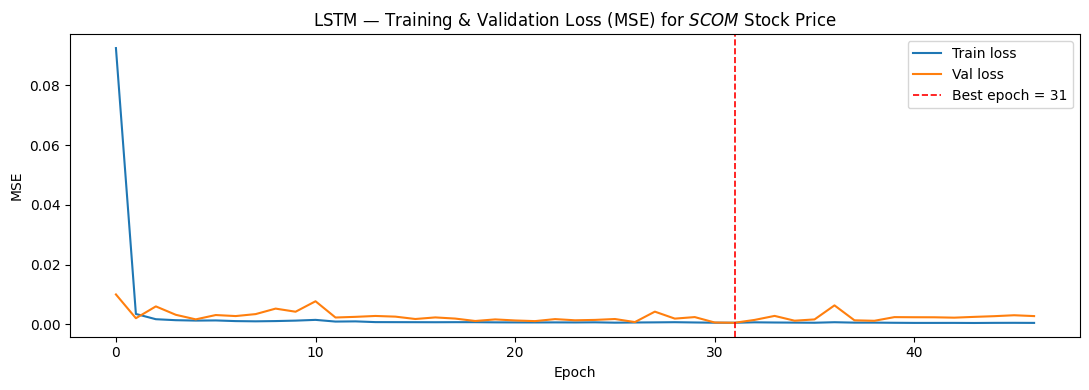

In [27]:
## LSTM Training Curves
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_losses,    label='Train loss', lw=1.5)
ax.plot(val_losses_hist, label='Val loss',   lw=1.5)
best_ep = int(np.argmin(val_losses_hist))
ax.axvline(best_ep, color='red', ls='--', lw=1.2, label=f'Best epoch = {best_ep}')
ax.set_title('LSTM — Training & Validation Loss (MSE) for ${SCOM}$ Stock Price')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()


In [28]:
## LSTM Predictions
lstm_val_preds_scaled  = model_predict(lstm_model, X_win_val)
lstm_test_preds_scaled = model_predict(lstm_model, X_win_test)

lstm_val_preds  = inv_transform(lstm_val_preds_scaled)
lstm_test_preds = inv_transform(lstm_test_preds_scaled)
y_val_actual    = inv_transform(y_win_val)
y_test_actual   = inv_transform(y_win_test)

print(f"LSTM val preds — min={lstm_val_preds.min():.2f}  max={lstm_val_preds.max():.2f}  mean={lstm_val_preds.mean():.2f}")
print(f"Actual val — min={y_val_actual.min():.2f}  max={y_val_actual.max():.2f}  mean={y_val_actual.mean():.2f}")
print(f"\nLSTM test preds — min={lstm_test_preds.min():.2f}  max={lstm_test_preds.max():.2f}  mean={lstm_test_preds.mean():.2f}")
print(f"Actual test — min={y_test_actual.min():.2f}  max={y_test_actual.max():.2f}  mean={y_test_actual.mean():.2f}")

LSTM val preds — min=3.13  max=4.72  mean=4.03
Actual val — min=2.15  max=5.00  mean=3.83

LSTM test preds — min=2.99  max=7.20  mean=3.76
Actual test — min=1.94  max=7.50  mean=3.26


---
## Section 9: xLSTM — Extended LSTM (PyTorch)

### What is xLSTM?
xLSTM (Beck et al., 2024 — "xLSTM: Extended Long Short-Term Memory") is an architectural evolution of LSTM with two key innovations:

#### 1. Exponential Gating (sLSTM — scalar LSTM)
In standard LSTM the input and forget gates are sigmoid-bounded in [0,1]. xLSTM introduces **exponential gates**:
$$i_t = e^{\hat{i}_t}, \quad f_t = e^{\hat{f}_t}$$
with a **normaliser** $m_t = \max(\log f_t + m_{t-1},\ \log i_t)$ to prevent overflow.
This allows the model to express much stronger selective forgetting or updating.

#### 2. Matrix Memory (mLSTM — matrix LSTM)
Instead of a scalar cell state $c_t \in \mathbb{R}^d$, mLSTM uses a **matrix cell state** $C_t \in \mathbb{R}^{d \times d}$:
$$C_t = f_t C_{t-1} + i_t\ v_t k_t^T$$
$$h_t = o_t \odot \frac{C_t q_t}{\max(|n_t^T q_t|, 1)}$$

This is effectively an **attention-like memory** that can retrieve any stored key-value pair in $O(1)$ time (unlike Transformers which are $O(n^2)$).

### xLSTM vs LSTM
| Feature | LSTM | xLSTM |
|---|---|---|
| Gate activation | Sigmoid (0–1) | Exponential (unbounded) |
| Memory structure | Scalar cell state | Matrix cell state (mLSTM) |
| Memory capacity | O(d) | O(d²) |
| Parallelisability | Sequential | Partially parallelisable |
| Context retention | Good | Superior for long sequences |

### Our Implementation
We implement the **mLSTM block** (matrix-memory variant) in PyTorch as it provides the strongest improvement over baseline LSTM for financial sequences. Our xLSTMCell uses:
- Causal query/key/value projections
- Exponential gating with normaliser for numerical stability
- A stack of xLSTM blocks followed by the same FC head as the LSTM


In [29]:
class mLSTMCell(nn.Module):
    """
    Matrix-memory LSTM cell (mLSTM) from xLSTM.

    The cell maintains a matrix memory C ∈ R^(head_dim x head_dim)
    and a normaliser n ∈ R^(head_dim), enabling O(1) retrieval of any
    stored representation — unlike standard LSTM which is limited to
    a single scalar cell state per hidden unit.

    Key equations (simplified):
        q = W_q x,  k = W_k x,  v = W_v x
        i = exp(W_i x + b_i)          # exponential input gate
        f = exp(W_f x + b_f + log m)  # exponential forget gate (stabilised)
        C = f * C_prev + i * outer(v, k)
        h = o * (C @ q) / max(|n · q|, eps)

    Parameters
    ----------
    input_size : features per time step
    head_dim   : dimension of Q, K, V projections (memory head size)
    """
    def __init__(self, input_size: int, head_dim: int):
        super().__init__()
        self.head_dim = head_dim

        # Projections for query, key, value
        self.W_q = nn.Linear(input_size, head_dim, bias=False)
        self.W_k = nn.Linear(input_size, head_dim, bias=False)
        self.W_v = nn.Linear(input_size, head_dim, bias=False)

        # Input gate (exp), forget gate (exp), output gate (sigmoid)
        self.w_i = nn.Linear(input_size, 1)
        self.w_f = nn.Linear(input_size, 1)
        self.w_o = nn.Linear(input_size, head_dim)

        # Layer norm on output
        self.ln  = nn.LayerNorm(head_dim)

    def forward(self, x, state):
        """
        x     : (batch, input_size)
        state : tuple(C, n, m)
            C  : matrix memory  (batch, head_dim, head_dim)
            n  : normaliser     (batch, head_dim)
            m  : log-max scalar (batch, 1)
        Returns
            h_out : (batch, head_dim)
            (C_new, n_new, m_new)
        """
        C, n, m = state

        q = self.W_q(x)                            # (B, D)
        k = self.W_k(x) / math.sqrt(self.head_dim) # (B, D) — scaled
        v = self.W_v(x)                            # (B, D)

        # Stabilised exponential gating
        i_tilde = self.w_i(x)                      # (B, 1)
        f_tilde = self.w_f(x)                      # (B, 1)
        m_new   = torch.max(f_tilde + m, i_tilde)  # (B, 1)
        i_gate  = torch.exp(i_tilde - m_new)       # (B, 1)
        f_gate  = torch.exp(f_tilde + m - m_new)   # (B, 1)

        # Matrix memory update: C = f * C + i * v ⊗ k
        # outer product: (B, D, 1) x (B, 1, D) = (B, D, D)
        outer   = torch.bmm(v.unsqueeze(2), k.unsqueeze(1))
        C_new   = f_gate.unsqueeze(-1) * C + i_gate.unsqueeze(-1) * outer

        # Normaliser update
        n_new   = f_gate * n + i_gate * k           # (B, D)

        # Retrieve: h = o * (C @ q) / max(|n · q|, eps)
        h_raw   = torch.bmm(C_new, q.unsqueeze(2)).squeeze(2)  # (B, D)
        denom   = torch.clamp(
            (n_new * q).sum(dim=1, keepdim=True).abs(), min=1.0)
        o_gate  = torch.sigmoid(self.w_o(x))        # (B, D)
        h_out   = o_gate * (h_raw / denom)
        h_out   = self.ln(h_out)

        return h_out, (C_new, n_new, m_new)

    def init_state(self, batch_size, device):
        """Initialise zero states."""
        return (
            torch.zeros(batch_size, self.head_dim, self.head_dim, device=device),
            torch.zeros(batch_size, self.head_dim, device=device),
            torch.zeros(batch_size, 1, device=device),
        )


class xLSTMBlock(nn.Module):
    """
    One xLSTM block: mLSTMCell + skip connection + dropout.

    The input is projected to head_dim (if needed), passed through mLSTMCell
    sequentially over time, and the output is projected back to input_size.
    This mirrors the residual-block pattern used in deep xLSTM stacks.
    """
    def __init__(self, input_size: int, head_dim: int, dropout: float = 0.1):
        super().__init__()
        self.cell    = mLSTMCell(input_size, head_dim)
        self.proj    = nn.Linear(head_dim, input_size)
        self.dropout = nn.Dropout(dropout)
        self.ln      = nn.LayerNorm(input_size)

    def forward(self, x):
        """
        x : (batch, seq_len, input_size)
        returns : (batch, seq_len, input_size)
        """
        B, T, D = x.shape
        state = self.cell.init_state(B, x.device)
        outs  = []
        for t in range(T):
            h, state = self.cell(x[:, t, :], state)
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)              # (B, T, head_dim)
        h_seq = self.proj(h_seq)                       # (B, T, input_size)
        return self.ln(x + self.dropout(h_seq))        # residual connection


class StockXLSTM(nn.Module):
    """
    Stacked xLSTM model for stock price forecasting.

    Architecture:
        Input projection → N × xLSTMBlock → Last-step dropout → FC head

    Parameters
    ----------
    input_size   : features per time step (F)
    hidden_size  : internal projection size (D) for each block
    num_layers   : number of stacked xLSTM blocks
    dropout      : dropout in blocks and FC head
    fc_units     : units in the intermediate FC layer
    """
    def __init__(self, input_size: int,
                 hidden_size: int = 64,
                 num_layers:  int = 2,
                 dropout:     float = 0.2,
                 fc_units:    int = 32):
        super().__init__()
        # Project input features to hidden_size
        self.input_proj = nn.Linear(input_size, hidden_size)

        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_size, fc_units)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(fc_units, 1)

    def forward(self, x):
        # x: (B, T, F)
        h = self.relu(self.input_proj(x))     # (B, T, hidden_size)
        for block in self.blocks:
            h = block(h)                       # residual xLSTM blocks
        h = self.dropout(h[:, -1, :])         # last time step
        h = self.relu(self.fc1(h))
        return self.fc2(h)                     # (B, 1)


# Sanity check
_demo_xl = StockXLSTM(input_size=n_features).to(device)
_x       = torch.randn(4, WINDOW_SIZE, n_features).to(device)
print(f"xLSTM demo output: {_demo_xl(_x).shape}")
print(f"Parameters       : {sum(p.numel() for p in _demo_xl.parameters()):,}")
print(_demo_xl)


xLSTM demo output: torch.Size([4, 1])
Parameters       : 44,421
StockXLSTM(
  (input_proj): Linear(in_features=4, out_features=64, bias=True)
  (blocks): ModuleList(
    (0-1): 2 x xLSTMBlock(
      (cell): mLSTMCell(
        (W_q): Linear(in_features=64, out_features=64, bias=False)
        (W_k): Linear(in_features=64, out_features=64, bias=False)
        (W_v): Linear(in_features=64, out_features=64, bias=False)
        (w_i): Linear(in_features=64, out_features=1, bias=True)
        (w_f): Linear(in_features=64, out_features=1, bias=True)
        (w_o): Linear(in_features=64, out_features=64, bias=True)
        (ln): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (proj): Linear(in_features=64, out_features=64, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (ln): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (

### Hyperparameter Tuning (xLSTM)
We use the same Bayesian Optimization (BO) search framework as for the LSTM, tuning an appropriately adjusted set of hyperparameters.

xLSTM is computationally heavier than LSTM because of the matrix outer products. We restrict the search via a wall-time approach where trials can be cancelled if they go beyond a specified wall-time. 

We also draw from the LSTM tuning results to implement Bayesian Optimization where: 
- We have an initial assumption that the best xLSTM hyperparameters are the same as the best LSTM hyperparameters (**Prior**)
- We perform the Bayesian Optimization for xLSTM hyperparameters (**Likelihood**)
- We obtain final xLSTM hyperparameter estimates given the data observed via Bayes Theorem (**Posterior**)
$$P(Hyperparams|Tuning)= \frac{P(Tuning|Hyperparams) \cdot P(Hyperparams)}{P(Tuning)}$$


In [30]:
## Budget 
total_budget_seconds = 2700 # 45 minutes total expected training time (Normal training runs could take hours especially with poor hardware so this is sufficiently short)
max_trial_seconds= 400  # Any trial still running after this many seconds is pruned (10 mins max)
xlstm_epochs= 20 # Can be kept short. With the per-trial time cap, large configs will be pruned before completing all epochs anyway
xlstm_trials= 25
xlstm_startup= 5 # Number of random trials before the GP surrogoate is applied

## Early Stopping
xlstm_es_patience  = 5    # epochs to wait after last improvement
xlstm_es_min_delta = 1e-5 # minimum improvement to count as progress

## Warm-start: map LSTM posterior onto widened xLSTM search space
# lstm_best_params is used as trial 0 (enqueue_trial). 
# It's a useful anchor even with wider ranges since.....
#.....the GP starts with one high-quality observation rather than purely random startup trials.

# Batch size grid
BATCH_GRID = [32, 64, 128]

## Clipping
# np.clip() for float and int values
# _clip_to_grid() for categorical values
# Clipping is for in the event the best LSTM values are outside the xLSTM parameter space defined
# Such values are clipped to the upper or lower bound value
# This is useful for instances where we may want to limit the xLSTM search space as it is significantly more intensive to train 
def _clip_to_grid(value, grid):
    """Nearest-value snap for categorical params only."""
    return min(grid, key=lambda g: abs(g - value))

def _snap_to_step(value, low, high, step):
    """Snap an integer value to the nearest multiple of step within [low, high]."""
    snapped = round((value - low) / step) * step + low
    return int(np.clip(snapped, low, high))

lstm_seed = {
    # suggest_int — snap to step=16 grid, wider bounds
    'hidden_size': _snap_to_step(int(lstm_best_params['hidden_size']), 64, 256, 16),
    'fc_units'   : _snap_to_step(int(lstm_best_params['fc_units']),    32, 256, 16),

    # suggest_int — no step, just clip to widened range
    'num_layers' : int(np.clip(int(lstm_best_params['num_layers']), 1, 4)),

    # suggest_float — clip to widened continuous range
    'dropout'    : float(np.clip(float(lstm_best_params['dropout']), 0.2, 0.3)), # Clip dropout to a small beginning range
    'lr'         : float(np.clip(float(lstm_best_params['lr']),      0.0001, 0.01)),

    # suggest_categorical — snap to nearest grid value
    'batch_size' : int(_clip_to_grid(int(lstm_best_params['batch_size']), BATCH_GRID)),}

print("xLSTM warm-start (LSTM posterior mapped to a widened xLSTM space):")
for k, v in lstm_seed.items():
    print(f"  {k:15s}: {v}")


## Objective function
xl_search_results = []
def xl_objective(trial: optuna.Trial) -> float:

    ## Hyperparameters
    hidden_size = trial.suggest_int("hidden_size", 64, 256,  step=16)
    num_layers  = trial.suggest_int("num_layers", 1, 4)
    fc_units    = trial.suggest_int("fc_units",32, 256,  step=32)
    dropout     = trial.suggest_float("dropout", 0.1, 0.5)
    lr          = trial.suggest_float("lr", 0.0001, 0.005, log=True)
    batch_size  = trial.suggest_categorical("batch_size", BATCH_GRID)

    ## Soft cost heuristic
    # xLSTM cost per step scales as O(hidden_size² × num_layers).
    # We compute an approximate relative cost and tighten the per-trial
    # time cap for expensive configs. This prevents the GP from freely
    # proposing large configs without paying a proportional time penalty.
    # cost_factor is normalised so that hidden=64, layers=1 → factor=1.0
    # (baseline). hidden=256, layers=4 → factor=64.0 (64× more expensive).
    cost_factor= (hidden_size / 64) ** 2 * num_layers
    trial_time_limit = max_trial_seconds / max(cost_factor ** 0.5, 1.0)
    trial_start= time.time()

    ## Build model, optimiser, data loader 
    model_t = StockXLSTM(
        input_size  = n_features,
        hidden_size = hidden_size,
        num_layers  = num_layers,
        dropout     = dropout,
        fc_units    = fc_units).to(device)

    opt_t     = torch.optim.Adam(model_t.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_ld  = make_data_loader(X_win_train, y_win_train, batch_size, shuffle=True)
    best_vl      = float('inf')
    es_counter   = 0          # epochs since last improvement
    es_stopped_epoch = None

    ## Training loop with dual pruning + early stopping
    for ep in range(xlstm_epochs):

        # Train one epoch
        model_t.train()
        for Xb, yb in train_ld:
            opt_t.zero_grad()
            loss = criterion(model_t(Xb.to(device)), yb.to(device))
            loss.backward()
            # Gradient clipping: xLSTM's exponential gates can produce
            # large gradients — clipping at 1.0 prevents instability.
            nn.utils.clip_grad_norm_(model_t.parameters(), 1.0)
            opt_t.step()

        # Validate
        val_preds = model_predict(model_t, X_win_val)
        val_loss  = mean_squared_error(y_win_val, val_preds)

        # Early stopping check (before reporting to pruner)
        # Runs first — if the trial has plateaued within itself,
        # there's no point feeding a stale val_loss to the MedianPruner.
        if val_loss < (best_vl - xlstm_es_min_delta):
            best_vl    = val_loss
            es_counter = 0
        else:
            es_counter += 1
            if es_counter >= xlstm_es_patience:
                es_stopped_epoch = ep
                break   # exit epoch loop, return best_vl seen so far

        # Pruning check 1 — MedianPruner (performance-based)
        # Kills trials whose val_loss is worse than the median of all
        # other trials at the same epoch.
        trial.report(val_loss, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Pruning check 2 — wall-time cap (cost-based)
        # Kills trials that have consumed their per-trial time budget.
        # Particularly important for large hidden_size / num_layers configs
        # that would otherwise dominate total wall-time.
        elapsed = time.time() - trial_start
        if elapsed > trial_time_limit:
            raise optuna.exceptions.TrialPruned()

    xl_search_results.append({
        'hidden_size': hidden_size, 'num_layers': num_layers,
        'fc_units': fc_units, 'dropout': dropout,
        'lr': lr,'batch_size': batch_size,
        'val_loss': best_vl,})
    return best_vl


# ── 3. Build study ────────────────────────────────────────────────────────────
#
# deterministic_objective=False: the GP models val_loss as noisy.
#   Mini-batch SGD is stochastic — the same hyperparameters give slightly
#   different val_loss values across runs. 

# MedianPruner — n_startup_trials raised to 6 to match XL_STARTUP.
#   Don't allow pruning until the same number of trials that seeded the
#   GP have completed — the median estimate is unreliable before then.
#
sampler = TPESampler(n_startup_trials= xlstm_startup, seed= seed)

pruner = MedianPruner(n_startup_trials = xlstm_startup, n_warmup_steps= xlstm_startup)

xl_study = optuna.create_study(
    direction  = "minimize",
    sampler    = sampler,
    pruner     = pruner,
    study_name = "xlstm_bayes_opt")


## Inject LSTM prior as trial 0
xl_study.enqueue_trial(lstm_seed)


## Run optimisation with wall-time budget
# timeout=TOTAL_BUDGET_SECONDS replaces n_trials as the primary budget.
# Optuna keeps launching trials until the wall-time is exhausted. Cheap
# configs (small hidden_size, few layers) naturally complete more trials
# within the budget; expensive configs complete fewer. The GP handles
# this mixed-cost regime correctly — it models outcomes, not costs.
#
# n_trials is set as a safety cap (prevents runaway if trials are very fast).
print(f"\nxLSTM Bayesian Optimisation")
print(f"  Wall-time budget : {total_budget_seconds // 60} minutes")
print(f"  Max per trial    : {max_trial_seconds // 60} minutes (scaled by config cost)")
print(f"  GP startup trials: {xlstm_startup}")
print(f"  Search space     : hidden [32-256] · layers [1-4] · lr [1e-4, 1e-1] · "
      f"dropout [0.05-0.5] · fc [16-256] · batch {BATCH_GRID}\n")

xl_study.optimize(xl_objective,
                 n_trials= xlstm_trials, # safety cap
                 timeout= total_budget_seconds,  # primary budget
                 show_progress_bar = True)


## Extract best hyperparameters 
xl_best_params = xl_study.best_params | {'val_loss': xl_study.best_value}

n_complete = len([t for t in xl_study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned   = len([t for t in xl_study.trials if t.state == optuna.trial.TrialState.PRUNED])

print(f"\n{'='*54}")
print(f"Best xLSTM hyperparameters (trial #{xl_study.best_trial.number + 1}):")
for k, v in xl_best_params.items():
    print(f"  {k:15s}: {v}")
print(f"\n  Completed trials : {n_complete}")
print(f"  Pruned trials    : {n_pruned}")
print(f"  Total trials run : {n_complete + n_pruned}")


## Results DataFrame
xl_results_df= (xl_study.trials_dataframe(attrs=("number", "value", "params", "state"))
               .rename(columns={"value": "val_loss"})
               .sort_values("val_loss"))
completed = xl_results_df[xl_results_df["state"] == "COMPLETE"]
print(f"\nCompleted trials (sorted by val_loss):")
print(completed.to_string(index=False))


## Hyperparameter importance
try:
    importance = optuna.importance.get_param_importances(xl_study)
    print(f"\nHyperparameter importances (fANOVA):")
    for param, imp in importance.items():
        bar = "█" * int(imp * 30)
        print(f"  {param:15s}: {bar:<30s} {imp:.3f}")
except Exception:
    pass


## Optional: posterior visualisations (requires plotly)
# import optuna.visualization as vis
# vis.plot_optimization_history(xl_study).show()
# vis.plot_param_importances(xl_study).show()
# vis.plot_contour(xl_study, params=["hidden_size", "lr"]).show()
# vis.plot_parallel_coordinate(xl_study).show()

xLSTM warm-start (LSTM posterior mapped to a widened xLSTM space):
  hidden_size    : 160
  fc_units       : 256
  num_layers     : 2
  dropout        : 0.3
  lr             : 0.007568292060167618
  batch_size     : 128

xLSTM Bayesian Optimisation
  Wall-time budget : 45 minutes
  Max per trial    : 6 minutes (scaled by config cost)
  GP startup trials: 5
  Search space     : hidden [32-256] · layers [1-4] · lr [1e-4, 1e-1] · dropout [0.05-0.5] · fc [16-256] · batch [32, 64, 128]



  0%|          | 0/25 [00:00<?, ?it/s]


Best xLSTM hyperparameters (trial #9):
  hidden_size    : 112
  num_layers     : 1
  fc_units       : 96
  dropout        : 0.22870687104010595
  lr             : 0.0021012804322965207
  batch_size     : 128
  val_loss       : 5.09640260853922e-05

  Completed trials : 15
  Pruned trials    : 10
  Total trials run : 25

Completed trials (sorted by val_loss):
 number  val_loss  params_batch_size  params_dropout  params_fc_units  params_hidden_size  params_lr  params_num_layers    state
      8  0.000051                128        0.228707               96                 112   0.002101                  1 COMPLETE
      9  0.000058                128        0.412700               64                 208   0.002748                  1 COMPLETE
     16  0.000100                128        0.258885               96                 176   0.003711                  1 COMPLETE
     13  0.000144                128        0.377927               96                 256   0.001963                  1 CO

In [31]:
## Full xLSTM Training
xlstm_ckpt = os.path.join(CKPT_DIR, 'xlstm_best.pt')

xlstm_model = StockXLSTM(
    input_size  = n_features,
    hidden_size = int(xl_best_params['hidden_size']),
    num_layers  = int(xl_best_params['num_layers']),
    dropout     = float(xl_best_params['dropout']),
    fc_units    = int(xl_best_params['fc_units'])).to(device)

xl_optimizer  = torch.optim.Adam(xlstm_model.parameters(), lr=float(xl_best_params['lr']))
xl_scheduler  = ReduceLROnPlateau(xl_optimizer, 'min', patience=7, factor=0.5)
criterion     = nn.MSELoss()
xl_train_ld   = make_data_loader(X_win_train, y_win_train,
                                  int(xl_best_params['batch_size']), shuffle=True)

xl_train_losses, xl_val_losses = [], []
xl_best_val_loss = float('inf')
xl_no_improve    = 0
xl_max_epochs    = 150
xl_patience      = 15
CKPT_FREQ        = 10

print(f"Training xLSTM | hidden={int(xl_best_params['hidden_size'])}  "
      f"layers={int(xl_best_params['num_layers'])}  "
      f"dropout={xl_best_params['dropout']}  lr={xl_best_params['lr']}")

for epoch in range(1, xl_max_epochs + 1):
    xlstm_model.train()
    ep_loss = 0.0
    for Xb, yb in xl_train_ld:
        xl_optimizer.zero_grad()
        loss = criterion(xlstm_model(Xb.to(device)), yb.to(device))
        loss.backward()
        nn.utils.clip_grad_norm_(xlstm_model.parameters(), 1.0)
        xl_optimizer.step()
        ep_loss += loss.item() * len(Xb)
    ep_loss /= len(X_win_train)

    val_preds = model_predict(xlstm_model, X_win_val)
    val_loss  = mean_squared_error(y_win_val, val_preds)
    xl_scheduler.step(val_loss)

    xl_train_losses.append(ep_loss)
    xl_val_losses.append(val_loss)

    if val_loss < xl_best_val_loss:
        xl_best_val_loss = val_loss
        xl_no_improve    = 0
        save_checkpoint({
            'model_state'    : xlstm_model.state_dict(),
            'optimizer_state': xl_optimizer.state_dict(),
            'epoch'          : epoch,
            'val_loss'       : xl_best_val_loss,
            'hyperparams'    : xl_best_params,
        }, xlstm_ckpt)
    else:
        xl_no_improve += 1

    if epoch % CKPT_FREQ == 0:
        save_checkpoint({
            'model_state': xlstm_model.state_dict(),
            'epoch'      : epoch,
            'val_loss'   : val_loss,
        }, os.path.join(CKPT_DIR, f'xlstm_epoch_{epoch}.pt'))

    if epoch % 20 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{xl_max_epochs}  train={ep_loss:.6f}  "
              f"val={val_loss:.6f}  best={xl_best_val_loss:.6f}  "
              f"no_improve={xl_no_improve}")

    if xl_no_improve >= xl_patience:
        print(f"  Early stopping at epoch {epoch}")
        break

load_checkpoint(xlstm_ckpt, xlstm_model)
print(f"\nxLSTM training complete. Best val_loss = {xl_best_val_loss:.6f}")


Training xLSTM | hidden=112  layers=1  dropout=0.22870687104010595  lr=0.0021012804322965207


  Epoch   1/150  train=0.060102  val=0.019493  best=0.019493  no_improve=0
  Epoch  20/150  train=0.000993  val=0.001932  best=0.001545  no_improve=2
  Epoch  40/150  train=0.000781  val=0.001784  best=0.001152  no_improve=7
  Early stopping at epoch 48

xLSTM training complete. Best val_loss = 0.001152


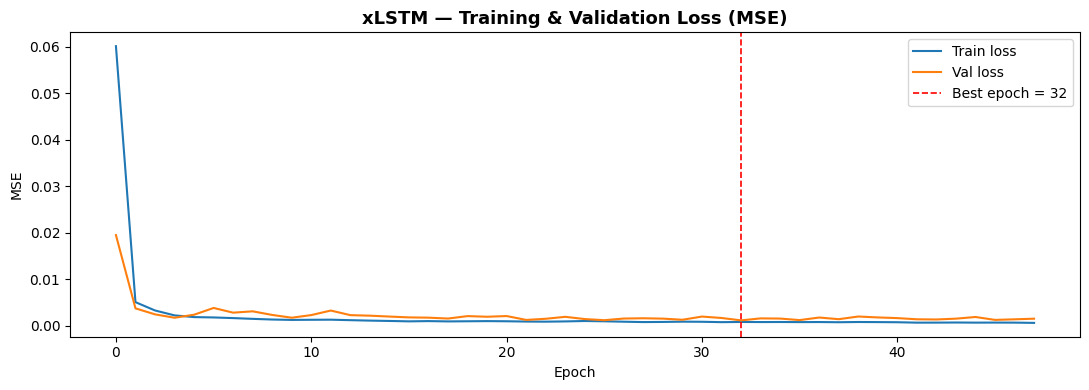

In [32]:
## xLSTM Training Curves
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(xl_train_losses, label='Train loss', lw=1.5)
ax.plot(xl_val_losses,   label='Val loss',   lw=1.5)
best_ep = int(np.argmin(xl_val_losses))
ax.axvline(best_ep, color='red', ls='--', lw=1.2, label=f'Best epoch = {best_ep}')
ax.set_title('xLSTM — Training & Validation Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()

In [33]:
## xLSTM Predictions
xlstm_val_preds_scaled  = model_predict(xlstm_model, X_win_val)
xlstm_test_preds_scaled = model_predict(xlstm_model, X_win_test)

xlstm_val_preds  = inv_transform(xlstm_val_preds_scaled)
xlstm_test_preds = inv_transform(xlstm_test_preds_scaled)

print(f"xLSTM val preds — min={xlstm_val_preds.min():.2f}  max={xlstm_val_preds.max():.2f}  mean={xlstm_val_preds.mean():.2f}")
print(f"Actual val — min={y_val_actual.min():.2f}  max={y_val_actual.max():.2f}  mean={y_val_actual.mean():.2f}")
print(f"\nxLSTM test preds — min={xlstm_test_preds.min():.2f}  max={xlstm_test_preds.max():.2f}  mean={xlstm_test_preds.mean():.2f}")
print(f"Actual test — min={y_test_actual.min():.2f}  max={y_test_actual.max():.2f}  mean={y_test_actual.mean():.2f}")

xLSTM val preds — min=3.49  max=4.36  mean=4.00
Actual val — min=2.15  max=5.00  mean=3.83

xLSTM test preds — min=3.34  max=7.12  mean=3.93
Actual test — min=1.94  max=7.50  mean=3.26


---
## Section 10: Decoder-only Transformer (PyTorch)

### What is a Transformer?
The Transformer (Vaswani et al., 2017) replaces recurrence entirely with **self-attention**, allowing every position in the sequence to attend to every other position in parallel.

#### Core Components
1. **Positional Encoding**: since attention is permutation-invariant, we inject positional information using sinusoidal encodings:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

2. **Multi-Head Self-Attention (MHSA)**: queries, keys, and values are linearly projected $h$ times, attention is computed in parallel across heads, and results are concatenated:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

3. **Feed-Forward Network (FFN)**: a two-layer MLP applied position-wise after attention.

4. **Causal Masking**: in a decoder-only design, each position can only attend to *previous* positions. This is critical for autoregressive forecasting — no look-ahead leakage.

### Decoder-only vs Encoder-Decoder
We use a **decoder-only** architecture (like GPT) for several reasons:
- In time series forecasting, we generate future values **autoregressively** from past observations
- The encoder-decoder split (like the original Transformer) is designed for sequence-to-sequence translation where source and target are different modalities
- Decoder-only is simpler, faster to train, and achieves strong empirical performance on temporal data

### Why Transformer for Stock Prices?
- Captures both **local** (recent days) and **global** (multi-month) temporal dependencies via attention
- Parallelisable over sequence positions (unlike LSTMs which are sequential)
- The causal mask naturally enforces temporal order without explicit recurrence
- Scales well with more data

### Our Architecture
```
Input (B, T, F)
  → Linear projection to d_model
  → + Positional Encoding
  → N × Decoder Block:
      [Causal Multi-Head Self-Attention → Add & Norm]
      [Feed-Forward Network → Add & Norm]
  → Last time step
  → FC head (d_model → fc_units → 1)
```


In [34]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al., 2017).

    Creates a (max_len, d_model) encoding matrix added to the
    input embeddings to inject positional information.

    Unlike learned positional embeddings, sinusoidal encodings:
    - Generalise to sequences longer than seen during training
    - Have no trainable parameters
    - Preserve relative distance information through linear combinations
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])

        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1), :])


class DecoderBlock(nn.Module):
    """
    A single Transformer decoder block with:
    - Causal multi-head self-attention (no cross-attention — decoder-only)
    - Position-wise feed-forward network
    - Residual connections and layer normalisation

    The causal mask ensures that position t can only attend to positions ≤ t,
    preventing look-ahead and respecting the temporal ordering of the series.
    """
    def __init__(self, d_model: int, n_heads: int,
                 ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.attn    = nn.MultiheadAttention(d_model, n_heads,
                                             dropout=dropout,
                                             batch_first=True)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None):
        """
        x           : (B, T, d_model)
        causal_mask : (T, T) additive mask, -inf for forbidden positions
        """
        # Self-attention with causal mask → add & norm
        attn_out, _ = self.attn(x, x, x,
                                attn_mask=causal_mask,
                                is_causal=True)
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward → add & norm
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class StockTransformer(nn.Module):
    """
    Decoder-only Transformer for financial time series forecasting.

    Architecture:
        Input (B, T, F)
        → Linear projection: F → d_model
        → Sinusoidal positional encoding
        → N × DecoderBlock (causal self-attention + FFN)
        → Last time step: (B, d_model)
        → Dropout → FC1 → GELU → FC2 → (B, 1)

    Parameters
    ----------
    input_size : number of input features (F)
    d_model    : internal embedding dimension
    n_heads    : number of attention heads (d_model must be divisible by n_heads)
    num_layers : number of stacked decoder blocks
    ff_dim     : feed-forward intermediate dimension (typically 4 × d_model)
    dropout    : dropout rate in attention, FFN, and head
    fc_units   : intermediate FC dimension before the output scalar
    max_len    : maximum sequence length for positional encoding
    """
    def __init__(self, input_size: int,
                 d_model:    int = 64,
                 n_heads:    int = 4,
                 num_layers: int = 2,
                 ff_dim:     int = 256,
                 dropout:    float = 0.1,
                 fc_units:   int = 32,
                 max_len:    int = 512):
        super().__init__()

        # Ensure d_model is divisible by n_heads
        assert d_model % n_heads == 0, (
            f"d_model ({d_model}) must be divisible by n_heads ({n_heads})")

        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = SinusoidalPositionalEncoding(d_model, max_len, dropout)

        self.blocks     = nn.ModuleList([
            DecoderBlock(d_model, n_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.dropout    = nn.Dropout(dropout)
        self.fc1        = nn.Linear(d_model, fc_units)
        self.act        = nn.GELU()
        self.fc2        = nn.Linear(fc_units, 1)

        # Initialise weights with Xavier uniform for stable training
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        """
        x : (B, T, F)
        """
        B, T, _ = x.shape

        # Build causal mask: upper triangle = -inf
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=x.device)

        h = self.act(self.input_proj(x))          # (B, T, d_model)
        h = self.pos_enc(h)

        for block in self.blocks:
            h = block(h, causal_mask)

        h = self.dropout(h[:, -1, :])             # last position
        h = self.act(self.fc1(h))
        return self.fc2(h)                        # (B, 1)


# Sanity check
_demo_tf = StockTransformer(input_size=n_features).to(device)
_x       = torch.randn(4, WINDOW_SIZE, n_features).to(device)
print(f"Transformer demo output: {_demo_tf(_x).shape}")
print(f"Parameters             : {sum(p.numel() for p in _demo_tf.parameters()):,}")
print(_demo_tf)


Transformer demo output: torch.Size([4, 1])
Parameters             : 102,401
StockTransformer(
  (input_proj): Linear(in_features=4, out_features=64, bias=True)
  (pos_enc): SinusoidalPositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-1): 2 x DecoderBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (act): GELU(app

### Hyperparameter Tuning (Transformer)
Key hyperparameters for the Transformer:

| Parameter | Search Space | Notes |
|---|---|---|
| `d_model` | 32, 64, 128 | Must be divisible by n_heads |
| `n_heads` | 2, 4 | Heads for d_model=32 use 2; d_model≥64 use 4 |
| `num_layers` | 1, 2, 3 | Decoder block stack depth |
| `ff_dim` | 64, 128, 256 | FFN hidden dim (typically 4×d_model) |
| `dropout` | 0.1, 0.2, 0.3 | In attention, FFN, and head |
| `lr` | 1e-3, 5e-4, 1e-4 | Transformers typically need a lower lr |
| `batch_size` | 32, 64, 128 | |

We enforce the constraint `d_model % n_heads == 0` during sampling.


In [35]:
## Budget
tf_total_budget_seconds= 2700
tf_max_trials_seconds= 400
tf_epochs= 50
tf_trials= 40
tf_startup= 7

## Early Stopping
tf_es_patience  = 7    # epochs to wait after last improvement (higher than xLSTM given tf_epochs=50)
tf_es_min_delta = 1e-5 # minimum improvement to count as progress

## Valid n_heads choices per d_model
# This lookup table pre-computes which head counts are valid for each
# d_model value. Used inside the objective to enforce the constraint that
# d_model % n_heads == 0. Defining it here (outside the objective) avoids
# recomputing it on every trial.
D_MODEL_CHOICES = [32, 64, 128, 256]
ALL_HEADS       = [1, 2, 4, 8]

VALID_HEADS = {
    d: [h for h in ALL_HEADS if d % h == 0]
    for d in D_MODEL_CHOICES}
# Result:
#   {32: [1, 2, 4, 8], 64: [1, 2, 4, 8], 128: [1, 2, 4, 8], 256: [1, 2, 4, 8]}
# All d_model values here are divisible by all head counts, but the
# lookup table is the correct pattern — if you add d_model=48 later,
# it would only allow heads [1, 2] automatically.

tf_batch_grid = [8, 16, 32, 64, 128, 256]


## Objective function 
tf_search_results = []

def tf_objective(trial: optuna.Trial) -> float:

    # ── 2a. Hyperparameter proposal ──────────────────────────────────────────
    #
    # d_model — categorical. Powers of 2 are standard in Transformer design;
    #   256 added as an upper bound (meaningful for financial time series with
    #   many features). Kept categorical because the valid head counts depend
    #   on d_model — easier to enumerate than to express as a constraint.
    #
    d_model = trial.suggest_categorical("d_model", D_MODEL_CHOICES)

    # n_heads — CONDITIONAL on d_model.
    #   The valid head choices are looked up from the pre-computed table.
    #   TPE handles conditional parameters natively: it builds separate
    #   density models for each branch of the conditional tree, so
    #   (d_model=64, n_heads=4) and (d_model=128, n_heads=4) are treated
    #   as distinct observations in separate conditional sub-spaces.
    #
    n_heads = trial.suggest_categorical(
        "n_heads", VALID_HEADS[d_model])

    # num_layers — suggest_int. Ordinal with meaningful interpolation;
    #   TPE can learn that layers=2 is "between" 1 and 3.
    #   Upper bound raised to 4 — deep Transformer stacks are valid and
    #   the residual connections keep gradients healthy.
    #
    num_layers = trial.suggest_int("num_layers", 1, 10)

    # ff_dim — expressed as a multiplier of d_model rather than an absolute
    #   value. This enforces the standard Transformer design convention that
    #   ff_dim = 2–4 × d_model, preventing incoherent configs like
    #   d_model=128, ff_dim=64 (a feedforward layer narrower than the model).
    #   The actual ff_dim is computed and stored for logging.
    #
    ff_mult= trial.suggest_categorical("ff_mult", [2, 3, 4, 5])
    ff_dim= d_model * ff_mult

    # fc_units — suggest_int. Ordinal; step=16 keeps values architecturally
    #   round. Range widened slightly: lower bound 16 allows aggressive
    #   bottlenecks; upper bound 128 allows richer heads for large d_model.
    #
    fc_units = trial.suggest_int("fc_units", 8, 400, step=16)

    # dropout — suggest_float (linear). Wider range than original;
    #   0.05 captures near-zero regularisation for well-regularised models.
    #
    dropout = trial.suggest_float("dropout", 0.05, 0.4)

    # lr — suggest_float (log-uniform). Wider range: 1e-4 lower bound for
    #   large models that need slower learning; 1e-2 upper bound.
    #   Original [1e-4, 1e-3] was quite narrow.
    #
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    # batch_size — categorical. Genuinely discrete; no interpolation.
    #   16 added for small-dataset / high-noise scenarios.
    #
    batch_size = trial.suggest_categorical("batch_size", tf_batch_grid)

    # ── 2b. Soft cost heuristic for per-trial time cap ────────────────────────
    #
    # Transformer attention cost scales as O(d_model² × num_layers).
    # Configs with large d_model and many layers get a tighter time budget
    # so they can't monopolise wall-time. Normalised so that
    # d_model=64, layers=1 → factor=1.0 (baseline).
    #
    cost_factor      = (d_model / 64) ** 2 * num_layers
    trial_time_limit = tf_max_trials_seconds / max(cost_factor ** 0.5, 1.0)
    trial_start      = time.time()

    # ── 2c. Build model, optimiser, scheduler, data loader ───────────────────
    model_t = StockTransformer(
        input_size = n_features,
        d_model    = d_model,
        n_heads    = n_heads,
        num_layers = num_layers,
        ff_dim     = ff_dim,
        dropout    = dropout,
        fc_units   = fc_units,
    ).to(device)

    # Adam with Transformer-standard betas and eps — carried from original.
    opt_t = torch.optim.Adam(
        model_t.parameters(),
        lr    = lr,
        betas = (0.9, 0.98),
        eps   = 1e-9,
    )

    # Cosine annealing: decays lr from the sampled value to lr/10 over
    # TF_EPOCHS steps. This is a simple but effective improvement over
    # flat LR for Transformers — the model makes large updates early and
    # refines with smaller updates later.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt_t,
        T_max  = tf_epochs,
        eta_min= lr / 10)

    criterion = nn.MSELoss()
    train_ld  = make_data_loader(
        X_win_train, y_win_train, batch_size, shuffle=True
    )
    best_vl      = float('inf')
    es_counter   = 0          # epochs since last improvement
    es_stopped_epoch = None

    # ── 2d. Training loop ────────────────────────────────────────────────────
    for ep in range(tf_epochs):

        # Train one epoch
        model_t.train()
        for Xb, yb in train_ld:
            opt_t.zero_grad()
            loss = criterion(model_t(Xb.to(device)), yb.to(device))
            loss.backward()
            # Gradient clipping: important for Transformers with large d_model
            # where attention weights can produce large gradient magnitudes.
            nn.utils.clip_grad_norm_(model_t.parameters(), 1.0)
            opt_t.step()

        # Step the cosine scheduler once per epoch (not per batch)
        scheduler.step()

        # Validate
        val_preds = model_predict(model_t, X_win_val)
        val_loss  = mean_squared_error(y_win_val, val_preds)

        # Early stopping check (before reporting to pruner)
        # Runs first — if the trial has plateaued within itself,
        # there's no point feeding a stale val_loss to the MedianPruner.
        if val_loss < (best_vl - ES_MIN_DELTA):
            best_vl    = val_loss
            es_counter = 0
        else:
            es_counter += 1
            if es_counter >= tf_es_patience:
                es_stopped_epoch = ep
                break   # exit epoch loop, return best_vl seen so far

        # Pruning check 1 — MedianPruner (performance-based)
        trial.report(val_loss, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Pruning check 2 — wall-time cap (cost-based)
        if time.time() - trial_start > trial_time_limit:
            raise optuna.exceptions.TrialPruned()

    tf_search_results.append({
        'd_model'   : d_model,   'n_heads'   : n_heads,
        'num_layers': num_layers, 'ff_dim'    : ff_dim,
        'ff_mult'   : ff_mult,   'fc_units'  : fc_units,
        'dropout'   : dropout,   'lr'        : lr,
        'batch_size': batch_size, 'val_loss'  : best_vl,
    })
    return best_vl


# ── 3. Build study ────────────────────────────────────────────────────────────
#
# TPESampler chosen over GPSampler for three reasons specific to this problem:
#
#   1. Conditional parameter space. n_heads is conditional on d_model.
#      TPE handles conditional spaces via separate density models per branch.
#      GPSampler assumes a single smooth continuous surface and handles
#      conditional constraints less naturally.
#
#   2. Mixed types. The space has categoricals (d_model, n_heads, ff_mult,
#      batch_size), integers (num_layers, fc_units), and floats (dropout, lr).
#      TPE handles mixed types natively. GP works best in fully continuous
#      spaces and requires extra encoding for categoricals.
#
#   3. Scale. With a time budget of 60 minutes and fast cheap trials,
#      you may complete 20–40 trials. TPE scales to hundreds of trials;
#      GP degrades beyond ~100. TPE is the safer default here.
#
# multivariate=True: enables the multivariate TPE variant, which models
#   joint distributions over parameter pairs rather than treating each
#   parameter independently. This is important here because d_model and
#   n_heads are coupled — multivariate TPE learns this correlation.
#
sampler = TPESampler(
    seed         = seed,
    n_startup_trials = tf_startup,
    multivariate = True,
)

# MedianPruner: n_startup_trials matches TF_STARTUP so pruning doesn't
# begin before TPE has its own startup data. n_warmup_steps=15 is slightly
# higher than the xLSTM study — Transformers often take more epochs to
# show meaningful signal due to slower initial convergence.
#
pruner = MedianPruner(
    n_startup_trials = tf_startup,
    n_warmup_steps   = tf_startup,
)

tf_study = optuna.create_study(
    direction  = "minimize",
    sampler    = sampler,
    pruner     = pruner,
    study_name = "transformer_bayes_opt",
)


# ── 4. Optional warm-start ────────────────────────────────────────────────────
#
# If you have a prior best config (e.g. from a previous run or domain
# knowledge), inject it as trial 0. Unlike the xLSTM study where the LSTM
# posterior served as a prior, there is no direct analogue here unless you
# have a previous Transformer result to transfer from.
#
# To use: uncomment and populate tf_prior with known-good values.
# ff_mult must be the multiplier (2, 3, or 4), not the absolute ff_dim.
#
# tf_prior = {
#     'd_model'   : 64,
#     'n_heads'   : 4,
#     'num_layers': 2,
#     'ff_mult'   : 4,
#     'fc_units'  : 64,
#     'dropout'   : 0.1,
#     'lr'        : 1e-3,
#     'batch_size': 64,
# }
# tf_study.enqueue_trial(tf_prior)


# ── 5. Run optimisation ───────────────────────────────────────────────────────
print(f"\nTransformer Bayesian Optimisation")
print(f"  Sampler          : TPE (multivariate=True)")
print(f"  Wall-time budget : {tf_total_budget_seconds // 60} minutes")
print(f"  Max per trial    : {tf_max_trials_seconds // 60} min (scaled by config cost)")
print(f"  Startup trials   : {tf_startup}")
print(f"  d_model choices  : {D_MODEL_CHOICES}")
print(f"  Valid heads      : {VALID_HEADS}")
print(f"  ff_dim           : d_model × {{2, 3, 4}}\n")

tf_study.optimize(
    tf_objective,
    n_trials          = tf_trials,                    # safety cap
    timeout           = tf_total_budget_seconds,  # primary budget
    show_progress_bar = True,
)


# ── 6. Extract best hyperparameters ──────────────────────────────────────────
tf_best_params = tf_study.best_params | {'val_loss': tf_study.best_value}

# Reconstruct ff_dim from ff_mult for downstream use
tf_best_params['ff_dim'] = tf_best_params['d_model'] * tf_best_params['ff_mult']

n_complete = len([t for t in tf_study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned   = len([t for t in tf_study.trials
                  if t.state == optuna.trial.TrialState.PRUNED])

print(f"\n{'='*54}")
print(f"Best Transformer hyperparameters (trial #{tf_study.best_trial.number + 1}):")
for k, v in tf_best_params.items():
    print(f"  {k:15s}: {v}")
print(f"\n  Completed trials : {n_complete}")
print(f"  Pruned trials    : {n_pruned}")
print(f"  Total trials run : {n_complete + n_pruned}")


# ── 7. Results DataFrame ──────────────────────────────────────────────────────
tf_results_df = (
    tf_study.trials_dataframe(attrs=("number", "value", "params", "state"))
            .rename(columns={"value": "val_loss"})
            .sort_values("val_loss")
)
completed = tf_results_df[tf_results_df["state"] == "COMPLETE"]
print(f"\nCompleted trials (sorted by val_loss):")
print(completed.to_string(index=False))


# ── 8. Hyperparameter importance ─────────────────────────────────────────────
try:
    importance = optuna.importance.get_param_importances(tf_study)
    print(f"\nHyperparameter importances (fANOVA):")
    for param, imp in importance.items():
        bar = "█" * int(imp * 30)
        print(f"  {param:15s}: {bar:<30s} {imp:.3f}")
except Exception:
    pass


Transformer Bayesian Optimisation
  Sampler          : TPE (multivariate=True)
  Wall-time budget : 45 minutes
  Max per trial    : 6 min (scaled by config cost)
  Startup trials   : 7
  d_model choices  : [32, 64, 128, 256]
  Valid heads      : {32: [1, 2, 4, 8], 64: [1, 2, 4, 8], 128: [1, 2, 4, 8], 256: [1, 2, 4, 8]}
  ff_dim           : d_model × {2, 3, 4}



  0%|          | 0/40 [00:00<?, ?it/s]


Best Transformer hyperparameters (trial #10):
  d_model        : 256
  n_heads        : 8
  num_layers     : 1
  ff_mult        : 5
  fc_units       : 280
  dropout        : 0.08178450737106775
  lr             : 0.00013632336618397213
  batch_size     : 8
  val_loss       : 0.00013767224253170203
  ff_dim         : 1280

  Completed trials : 35
  Pruned trials    : 5
  Total trials run : 40

Completed trials (sorted by val_loss):
 number  val_loss  params_batch_size  params_d_model  params_dropout  params_fc_units  params_ff_mult  params_lr  params_n_heads  params_num_layers    state
      9  0.000138                  8             256        0.081785              280               5   0.000136               8                  1 COMPLETE
     22  0.000151                  8             128        0.073275              168               5   0.000261               8                  1 COMPLETE
     29  0.000194                 64              32        0.062828              152        

In [36]:
## Full Transformer Training
tf_ckpt = os.path.join(CKPT_DIR, 'transformer_best.pt')

tf_model = StockTransformer(
    input_size = n_features,
    d_model    = int(tf_best_params['d_model']),
    n_heads    = int(tf_best_params['n_heads']),
    num_layers = int(tf_best_params['num_layers']),
    ff_dim     = int(tf_best_params['ff_dim']),
    dropout    = float(tf_best_params['dropout']),
    fc_units   = int(tf_best_params['fc_units']),
).to(device)

tf_optimizer = torch.optim.Adam(tf_model.parameters(),
                                 lr=float(tf_best_params['lr']),
                                 betas=(0.9, 0.98), eps=1e-9)
tf_scheduler = ReduceLROnPlateau(tf_optimizer, 'min', patience=7, factor=0.5)
criterion    = nn.MSELoss()
tf_train_ld  = make_data_loader(X_win_train, y_win_train,
                                 int(tf_best_params['batch_size']), shuffle=True)

tf_train_losses, tf_val_losses = [], []
tf_best_val_loss = float('inf')
tf_no_improve    = 0
tf_max_epochs    = 150
tf_patience      = 15

print(f"Training Transformer | d_model={int(tf_best_params['d_model'])}  "
      f"n_heads={int(tf_best_params['n_heads'])}  "
      f"layers={int(tf_best_params['num_layers'])}  "
      f"ff_dim={int(tf_best_params['ff_dim'])}  "
      f"lr={tf_best_params['lr']}")

for epoch in range(1, tf_max_epochs + 1):
    tf_model.train()
    ep_loss = 0.0
    for Xb, yb in tf_train_ld:
        tf_optimizer.zero_grad()
        loss = criterion(tf_model(Xb.to(device)), yb.to(device))
        loss.backward()
        nn.utils.clip_grad_norm_(tf_model.parameters(), 1.0)
        tf_optimizer.step()
        ep_loss += loss.item() * len(Xb)
    ep_loss /= len(X_win_train)

    val_preds = model_predict(tf_model, X_win_val)
    val_loss  = mean_squared_error(y_win_val, val_preds)
    tf_scheduler.step(val_loss)

    tf_train_losses.append(ep_loss)
    tf_val_losses.append(val_loss)

    if val_loss < tf_best_val_loss:
        tf_best_val_loss = val_loss
        tf_no_improve    = 0
        save_checkpoint({
            'model_state'    : tf_model.state_dict(),
            'optimizer_state': tf_optimizer.state_dict(),
            'epoch'          : epoch,
            'val_loss'       : tf_best_val_loss,
            'hyperparams'    : tf_best_params,
        }, tf_ckpt)
    else:
        tf_no_improve += 1

    if epoch % CKPT_FREQ == 0:
        save_checkpoint({
            'model_state': tf_model.state_dict(),
            'epoch'      : epoch,
            'val_loss'   : val_loss,
        }, os.path.join(CKPT_DIR, f'transformer_epoch_{epoch}.pt'))

    if epoch % 20 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{tf_max_epochs}  train={ep_loss:.6f}  "
              f"val={val_loss:.6f}  best={tf_best_val_loss:.6f}  "
              f"no_improve={tf_no_improve}")

    if tf_no_improve >= tf_patience:
        print(f"  Early stopping at epoch {epoch}")
        break

load_checkpoint(tf_ckpt, tf_model)
print(f"\nTransformer training complete. Best val_loss = {tf_best_val_loss:.6f}")


Training Transformer | d_model=256  n_heads=8  layers=1  ff_dim=1280  lr=0.00013632336618397213
  Epoch   1/150  train=0.059887  val=0.004393  best=0.004393  no_improve=0
  Epoch  20/150  train=0.001891  val=0.000452  best=0.000083  no_improve=5


  Early stopping at epoch 36

Transformer training complete. Best val_loss = 0.000071


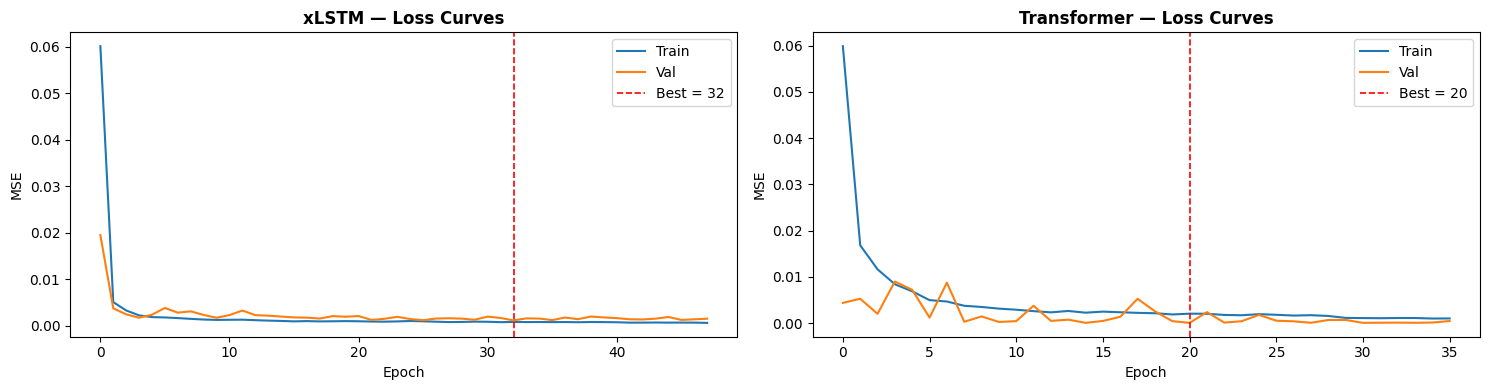

In [37]:
## Transformer Training Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, (tl, vl, title) in zip(axes, [
    (xl_train_losses, xl_val_losses,   'xLSTM'),
    (tf_train_losses, tf_val_losses,   'Transformer'),
]):
    ax.plot(tl, label='Train', lw=1.5)
    ax.plot(vl, label='Val',   lw=1.5)
    best_ep = int(np.argmin(vl))
    ax.axvline(best_ep, color='red', ls='--', lw=1.2, label=f'Best = {best_ep}')
    ax.set_title(f'{title} — Loss Curves', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()

plt.tight_layout()


In [38]:
## Transformer Predictions
tf_val_preds_scaled  = model_predict(tf_model, X_win_val)
tf_test_preds_scaled = model_predict(tf_model, X_win_test)

tf_val_preds  = inv_transform(tf_val_preds_scaled)
tf_test_preds = inv_transform(tf_test_preds_scaled)

print(f"Transformer val preds — min={tf_val_preds.min():.2f}  max={tf_val_preds.max():.2f}  mean={tf_val_preds.mean():.2f}")
print(f"Actual val — min={y_val_actual.min():.2f}  max={y_val_actual.max():.2f}  mean={y_val_actual.mean():.2f}")
print(f"\nTransformer test preds — min={tf_test_preds.min():.2f}  max={tf_test_preds.max():.2f}  mean={tf_test_preds.mean():.2f}")
print(f"Actual test — min={y_test_actual.min():.2f}  max={y_test_actual.max():.2f}  mean={y_test_actual.mean():.2f}")

Transformer val preds — min=2.38  max=4.71  mean=3.77
Actual val — min=2.15  max=5.00  mean=3.83

Transformer test preds — min=2.13  max=7.21  mean=3.23
Actual test — min=1.94  max=7.50  mean=3.26


---
## Section 11: Ensemble Construction — Ridge Regression Meta-Learner

### Model Stacking Intuition
Model stacking (Wolpert, 1992) learns **how to blend** the predictions of multiple base models using a second-level meta-learner. The key insight is:

- ARIMA captures **linear autocorrelation** and seasonal patterns
- LSTM / xLSTM / Transformer capture **non-linear temporal patterns**
- The meta-learner learns the optimal **weight allocation** between these complementary views

### Why Ridge Regression as Meta-Learner?
Ridge Regression (L2-regularised OLS) is the ideal meta-learner for ensemble blending because:
1. **Prevents overfitting**: the ridge penalty $\lambda \|\beta\|^2$ shrinks weights toward zero, avoiding over-reliance on any single model's idiosyncratic noise
2. **Handles multicollinearity**: base model predictions are often correlated; ridge handles this gracefully
3. **Interpretable weights**: the learned $\beta$ directly quantifies each model's contribution
4. **Data-efficient**: works well even with a limited number of meta-training examples

### No-Leakage Training Protocol
To avoid data leakage:
1. The ARIMA model predicts on a held-out validation window
2. The deep learning models predict on the same validation window (out-of-sample to the meta-learner)
3. The Ridge meta-learner is trained **only on these validation predictions**
4. It is evaluated on the completely held-out test set

This ensures the meta-learner never sees test-set labels during training.

### ARIMA Alignment
The ARIMA model predicts a fixed-size window. We align ARIMA predictions with LSTM/xLSTM/Transformer predictions by taking the last `N` ARIMA predictions to match the deep learning test window size.


In [39]:
len(df)

3881

In [40]:
in_sample_pred_arima  = arima_model.predict_in_sample()[:arima_train.shape[0]]
arima_val_preds= in_sample_pred_arima[-len(val_win_dates):]
arima_val_preds.shape

(517,)

In [41]:
n_val  = len(val_win_dates)
n_test = len(test_win_dates)

## Validation set trimming
val_win_dates= val_win_dates[-n_val:] # Dates
lstm_val_preds= lstm_val_preds[-n_val:]
xlstm_val_preds= xlstm_val_preds[-n_val:]
tf_val_preds= tf_val_preds[-n_val:]
y_val_actual= y_val_actual[-n_val:]

## Forecast horizon set trimming
test_win_dates   = test_win_dates[-n_test:] # Dates
lstm_test_preds  = lstm_test_preds[-n_test:]
xlstm_test_preds= xlstm_test_preds[-n_test:]
tf_test_preds= tf_test_preds[-n_test:]
y_test_actual= y_test_actual[-n_test:]

## Full Sets
full_lstm_set= np.concatenate([lstm_val_preds, lstm_test_preds])
full_xlstm_set = np.concatenate([xlstm_val_preds, xlstm_test_preds])
full_tf_set = np.concatenate([tf_val_preds, tf_test_preds])
full_actual_set = np.concatenate([y_val_actual, y_test_actual])



print(f"lstm_val_preds shape: {lstm_val_preds.shape}")
print(f"xlstm_val_preds shape: {xlstm_val_preds.shape}")
print(f"tf_val_preds shape: {tf_val_preds.shape}")
print(f"y_val_actual shape: {y_val_actual.shape}")

print(f"\nlstm_test_preds shape: {lstm_test_preds.shape}")
print(f"xlstm_test_preds shape: {xlstm_test_preds.shape}")
print(f"tf_test_preds shape: {tf_test_preds.shape}")
print(f"y_test_actual shape: {y_test_actual.shape}")

# Print full sets shapes in the requested format
print(f"\nfull_lstm_set shape: {full_lstm_set.shape}")
print(f"full_xlstm_set shape: {full_xlstm_set.shape}")
print(f"full_tf_set shape: {full_tf_set.shape}")
print(f"full_actual_set shape: {full_actual_set.shape}")

lstm_val_preds shape: (517,)
xlstm_val_preds shape: (517,)
tf_val_preds shape: (517,)
y_val_actual shape: (517,)

lstm_test_preds shape: (517,)
xlstm_test_preds shape: (517,)
tf_test_preds shape: (517,)
y_test_actual shape: (517,)

full_lstm_set shape: (1034,)
full_xlstm_set shape: (1034,)
full_tf_set shape: (1034,)
full_actual_set shape: (1034,)


In [42]:
## Trimming for ARIMA
## ARIMA val predictions (we use in-sample predictions sice ARIMA is not suited for long term predictions)
in_sample_pred_arima  = arima_model.predict_in_sample()[:arima_train.shape[0]]
arima_val_preds= in_sample_pred_arima[(-full_actual_set.shape[0] + forecast_horizon):] # Last value of this should be right before the out forecast period
full_arima_set= np.concatenate([arima_val_preds, arima_test_preds])

print(f'arima_val_preds shape: {arima_val_preds.shape}')
print(f'arima_test_pred shape: {arima_test_preds.shape}')
print(f'full_arima_set shape: {full_arima_set.shape}')
 # Shapes should be the same as above for other models

arima_val_preds shape: (1019,)
arima_test_pred shape: (15,)
full_arima_set shape: (1034,)


In [43]:
arima_val_preds.shape

(1019,)

In [44]:
## ── Build meta-feature matrices ─────────────────────────────────────────────
# Align lengths for ARIMA validation set and other models
arima_val_preds_ensemble= arima_val_preds[-n_val:].copy()

## Remember we are interested in the forecast horizon (the last n days)
lstm_test_preds_horizon = lstm_test_preds[-forecast_horizon:]
xlstm_test_preds_horizon = xlstm_test_preds[-forecast_horizon:]
tf_test_preds_horizon = tf_test_preds[-forecast_horizon:]
y_test_actual_horizon = y_test_actual[-forecast_horizon:]
arima_test_preds_horizon= arima_test_preds.copy()


# Val meta-features (for training the meta-learner)
meta_X_val_lstm = np.column_stack([arima_val_preds_ensemble, lstm_val_preds])
meta_X_val_xl   = np.column_stack([arima_val_preds_ensemble, xlstm_val_preds])
meta_X_val_tf   = np.column_stack([arima_val_preds_ensemble, tf_val_preds])

# Test meta-features (for evaluating the meta-learner) (Last n days)
meta_X_test_lstm = np.column_stack([arima_test_preds_horizon, lstm_test_preds_horizon])
meta_X_test_xl   = np.column_stack([arima_test_preds_horizon, xlstm_test_preds_horizon])
meta_X_test_tf   = np.column_stack([arima_test_preds_horizon, tf_test_preds_horizon])

# Val actuals (targets for training the meta-learner)
y_val_meta  = y_val_actual.copy()

print("Meta-feature matrices (val)  :", meta_X_val_lstm.shape)
print("Meta-feature matrices (test) :", meta_X_test_lstm.shape)


Meta-feature matrices (val)  : (517, 2)
Meta-feature matrices (test) : (15, 2)


In [45]:
## ── Ridge Meta-Learner Training ─────────────────────────────────────────────
# We use TimeSeriesSplit cross-validation to select the best Ridge alpha.
alphas= np.logspace(-2, 1, 30) # Between 10^-2= 0.001 and 10^1= 10 on a logarithmic scale
tscv= TimeSeriesSplit(n_splits=3, gap=2)

def best_ridge_alpha(meta_X, y, alphas, tscv):
    """Find the best Ridge alpha via time-series CV on meta features."""
    cv_scores = []
    for alpha in alphas:
        ridge  = Ridge(alpha=alpha)
        scores = []
        for tr, va in tscv.split(meta_X):
            ridge.fit(meta_X[tr], y[tr])
            preds = ridge.predict(meta_X[va])
            scores.append(mean_squared_error(y[va], preds))
        cv_scores.append(np.mean(scores))
    best_a = alphas[np.argmin(cv_scores)]
    return best_a, cv_scores

# Tune each ensemble separately
alpha_lstm, _ = best_ridge_alpha(meta_X_val_lstm, y_val_meta, alphas, tscv)
alpha_xl,   _ = best_ridge_alpha(meta_X_val_xl,   y_val_meta, alphas, tscv)
alpha_tf,   _ = best_ridge_alpha(meta_X_val_tf,   y_val_meta, alphas, tscv)

print(f"Best Ridge alpha — ARIMA+LSTM: {alpha_lstm:.4f}")
print(f"Best Ridge alpha — ARIMA+xLSTM: {alpha_xl:.4f}")
print(f"Best Ridge alpha — ARIMA+Transformer: {alpha_tf:.4f}")


Best Ridge alpha — ARIMA+LSTM: 1.4874
Best Ridge alpha — ARIMA+xLSTM: 0.0100
Best Ridge alpha — ARIMA+Transformer: 2.3950


In [46]:
## Ridge Regression
## Train final meta-learners on full val set 
meta_lstm = Ridge(alpha= alpha_lstm)
meta_xl   = Ridge(alpha= alpha_xl)
meta_tf   = Ridge(alpha= alpha_tf)

meta_lstm.fit(meta_X_val_lstm, y_val_meta)
meta_xl.fit(meta_X_val_xl,   y_val_meta)
meta_tf.fit(meta_X_val_tf,   y_val_meta)

print("Ridge meta-learner weights:")
print(f"  ARIMA+LSTM        — ARIMA={meta_lstm.coef_[0]:.4f}  LSTM={meta_lstm.coef_[1]:.4f}  intercept={meta_lstm.intercept_:.4f}")
print(f"  ARIMA+xLSTM       — ARIMA={meta_xl.coef_[0]:.4f}  xLSTM={meta_xl.coef_[1]:.4f}  intercept={meta_xl.intercept_:.4f}")
print(f"  ARIMA+Transformer — ARIMA={meta_tf.coef_[0]:.4f}  TF={meta_tf.coef_[1]:.4f}  intercept={meta_tf.intercept_:.4f}")

## Test-set ensemble predictions 
ensemble_lstm_test = meta_lstm.predict(meta_X_test_lstm)
ensemble_xl_test   = meta_xl.predict(meta_X_test_xl)
ensemble_tf_test   = meta_tf.predict(meta_X_test_tf)

## Save ARIMA model config
import joblib
joblib.dump(arima_model, os.path.join(CKPT_DIR, 'arima_model.pkl'))
joblib.dump({'meta_lstm': meta_lstm, 'meta_xl': meta_xl, 'meta_tf': meta_tf},
            os.path.join(CKPT_DIR, 'meta_learners.pkl'))
print(f"\nARIMA + meta-learners saved to {CKPT_DIR}/")

Ridge meta-learner weights:
  ARIMA+LSTM        — ARIMA=-0.0840  LSTM=1.3629  intercept=-1.3954
  ARIMA+xLSTM       — ARIMA=-0.0071  xLSTM=3.7681  intercept=-11.2131
  ARIMA+Transformer — ARIMA=-0.0319  TF=1.0471  intercept=-0.0213

ARIMA + meta-learners saved to /home/user/.ssh/KEGN/Models/


In [47]:
# ## NNLS helper — returns normalized non-negative weights
# def fit_nnls_meta(X, y):
#     coef, _ = nnls(X, y)
#     coef /= coef.sum()
#     return coef

# ## Train final meta-learners on full val set
# coef_lstm = fit_nnls_meta(meta_X_val_lstm, y_val_meta)
# coef_xl   = fit_nnls_meta(meta_X_val_xl,   y_val_meta)
# coef_tf   = fit_nnls_meta(meta_X_val_tf,   y_val_meta)

# print("NNLS meta-learner weights:")
# print(f"  ARIMA+LSTM        — ARIMA={coef_lstm[0]:.4f}  LSTM={coef_lstm[1]:.4f}")
# print(f"  ARIMA+xLSTM       — ARIMA={coef_xl[0]:.4f}    xLSTM={coef_xl[1]:.4f}")
# print(f"  ARIMA+Transformer — ARIMA={coef_tf[0]:.4f}    TF={coef_tf[1]:.4f}")

# ## Test-set ensemble predictions
# ensemble_lstm_test = meta_X_test_lstm @ coef_lstm
# ensemble_xl_test   = meta_X_test_xl   @ coef_xl
# ensemble_tf_test   = meta_X_test_tf   @ coef_tf

# ## Save ARIMA model config and NNLS coefficients
# import joblib
# joblib.dump(arima_model, os.path.join(CKPT_DIR, 'arima_model.pkl'))
# joblib.dump({'coef_lstm': coef_lstm, 'coef_xl': coef_xl, 'coef_tf': coef_tf},
#             os.path.join(CKPT_DIR, 'meta_learners.pkl'))
# print(f"\nARIMA + NNLS meta-learner coefficients saved to {CKPT_DIR}/")

---
## Section 12: Evaluation & Comparison

### Metrics
We evaluate all models on the **test set** (last N days — the same window across all models) using four complementary metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Penalises large errors heavily |
| **RMSE** | $\sqrt{MSE}$ | Same units as the target (KES) |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Robust to outliers |
| **MAPE** | $\frac{100}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right|$ | Scale-free, % interpretation |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained |

### Models Evaluated
1. ARIMA
2. LSTM
3. xLSTM *(new)*
4. Decoder-only Transformer *(new)*
5. ARIMA + LSTM Ensemble
6. ARIMA + xLSTM Ensemble *(new)*
7. ARIMA + Transformer Ensemble *(new)*


In [48]:
def evaluate(y_true, y_pred, label='Model'):
    """Compute comprehensive evaluation metrics."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Model': label, 'MSE': round(mse, 4),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'MAPE (%)': round(mape, 4), 'R²': round(r2, 4)}


results = []
results.append(evaluate(y_test_actual_horizon, arima_test_preds_horizon, 'ARIMA'))
results.append(evaluate(y_test_actual_horizon, lstm_test_preds_horizon, 'LSTM'))
results.append(evaluate(y_test_actual_horizon, xlstm_test_preds_horizon, 'xLSTM'))
results.append(evaluate(y_test_actual_horizon, tf_test_preds_horizon, 'Transformer'))
results.append(evaluate(y_test_actual_horizon, ensemble_lstm_test, 'ARIMA+LSTM'))
results.append(evaluate(y_test_actual_horizon, ensemble_xl_test, 'ARIMA+xLSTM'))
results.append(evaluate(y_test_actual_horizon, ensemble_tf_test, 'ARIMA+Transformer'))

final_results = pd.DataFrame(results).set_index('Model').sort_values(by= 'RMSE', ascending= True)
print("=" * 70)
print("FINAL MODEL EVALUATION — TEST SET")
print("=" * 70)
print(final_results.to_string())
print("=" * 70)


FINAL MODEL EVALUATION — TEST SET
                       MSE    RMSE     MAE  MAPE (%)         R²
Model                                                          
ARIMA+Transformer   0.0205  0.1432  0.1249    1.7293    -0.2193
LSTM                0.0367  0.1915  0.1759    2.4340    -1.1815
ARIMA               0.0478  0.2186  0.1787    2.4522    -1.8426
Transformer         0.0484  0.2201  0.2088    2.8949    -1.8817
xLSTM               0.0650  0.2549  0.2453    3.3989    -2.8640
ARIMA+LSTM          0.1570  0.3962  0.3869    5.3815    -8.3398
ARIMA+xLSTM        59.8656  7.7373  7.7321  107.4352 -3560.1660


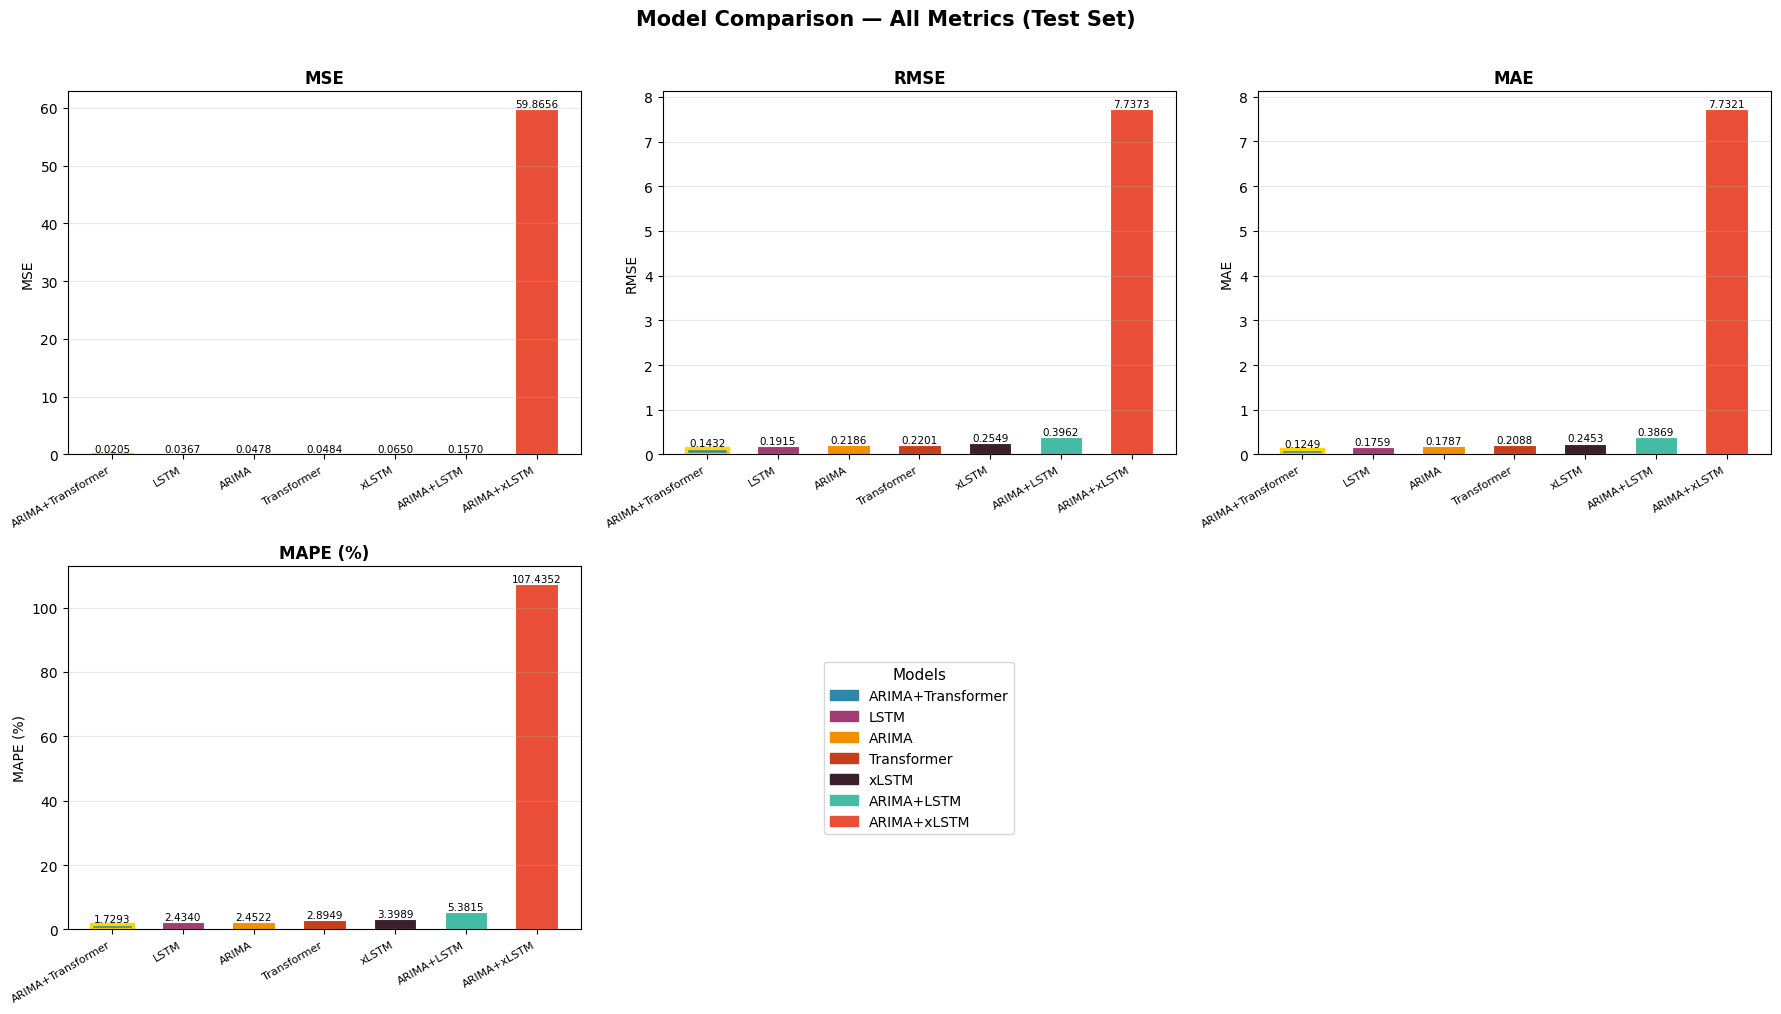

In [49]:
## ── Comprehensive Comparison Plot ────────────────────────────────────────────
metrics  = ['MSE', 'RMSE', 'MAE', 'MAPE (%)']
models   = final_results.index.tolist()
n_models = len(models)
n_metrics = len(metrics)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D',
          '#3B1F2B', '#44BBA4', '#E94F37']

for idx, metric in enumerate(metrics):
    ax     = axes[idx]
    vals   = final_results[metric].values
    bars   = ax.bar(models, vals, color=COLORS[:n_models],
                    edgecolor='white', linewidth=0.8, width=0.6)
    best_i = vals.argmin() if metric != 'R²' else vals.argmax()

    for i, (bar, v) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)
        if i == best_i:
            bar.set_edgecolor('gold')
            bar.set_linewidth(2.5)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide any unused subplots
for idx in range(n_metrics, len(axes)):
    axes[idx].axis('off')

# Legend (place it in the last subplot or a hidden one)
legend_patches = [mpatches.Patch(color=COLORS[i], label=models[i])
                  for i in range(n_models)]
axes[n_metrics].legend(handles=legend_patches, loc='center', fontsize=10,
                       title='Models', title_fontsize=11, frameon=True)

plt.suptitle('Model Comparison — All Metrics (Test Set)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

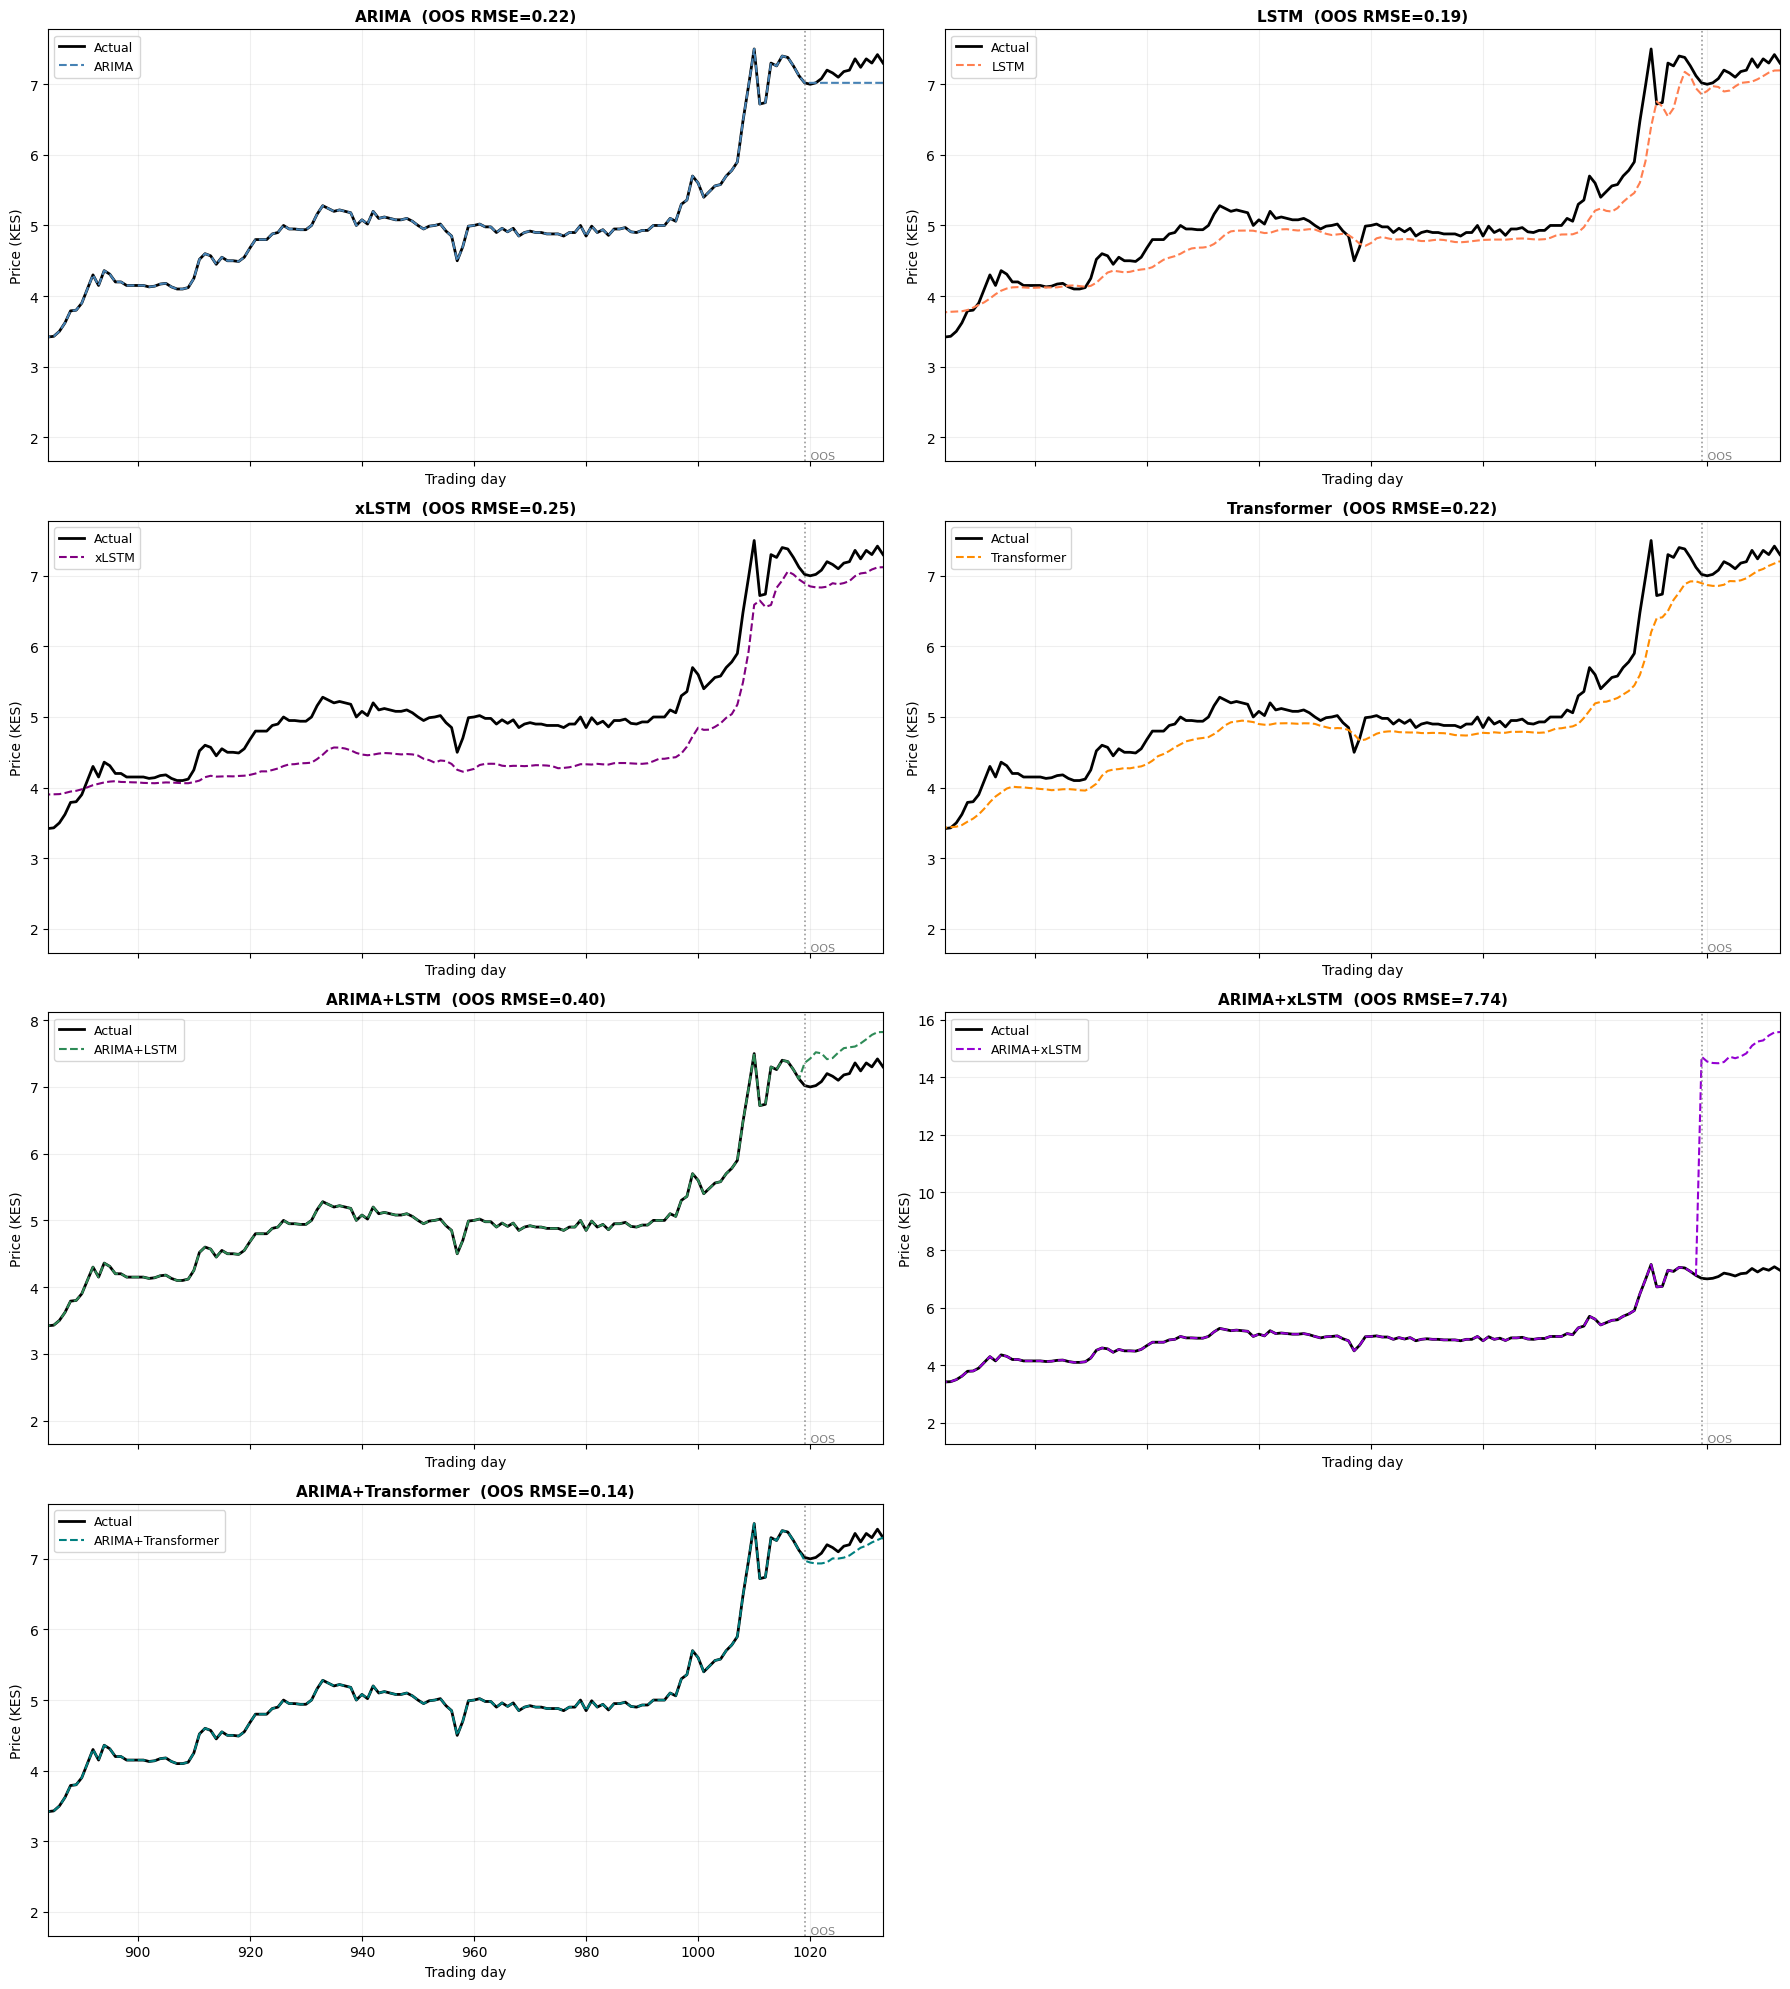

In [50]:
## ── Actual vs Predicted plots (full sets, index-based) ──────────────────────

n_full        = len(full_actual_set)
oos_start     = n_full - forecast_horizon
actual_prefix = full_actual_set[:oos_start]

full_ensemble_lstm = np.concatenate([actual_prefix, ensemble_lstm_test])
full_ensemble_xl   = np.concatenate([actual_prefix, ensemble_xl_test])
full_ensemble_tf   = np.concatenate([actual_prefix, ensemble_tf_test])

all_preds = [
    (full_arima_set,      'ARIMA',             'steelblue'),
    (full_lstm_set,       'LSTM',              'coral'),
    (full_xlstm_set,      'xLSTM',             'purple'),
    (full_tf_set,         'Transformer',       'darkorange'),
    (full_ensemble_lstm,  'ARIMA+LSTM',        'seagreen'),
    (full_ensemble_xl,    'ARIMA+xLSTM',       'darkviolet'),
    (full_ensemble_tf,    'ARIMA+Transformer', 'teal'),
]

x_index    = np.arange(n_full)
xlim_start = n_full - 150
xlim_end   = n_full - 1

fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True)
axes      = axes.flatten()

for i, (preds, label, color) in enumerate(all_preds):
    ax = axes[i]

    ax.plot(x_index, full_actual_set, label='Actual', lw=2, color='black')
    ax.plot(x_index, preds, label=label, lw=1.5, color=color, ls='--')

    ax.axvline(x=oos_start, color='gray', lw=1.2, ls=':', alpha=0.8)
    ax.text(oos_start + 0.5, ax.get_ylim()[0],
            ' OOS', fontsize=8, color='gray', va='bottom')

    oos_preds   = preds[oos_start:]
    oos_actuals = full_actual_set[oos_start:]
    rmse = np.sqrt(mean_squared_error(oos_actuals, oos_preds))
    ax.set_title(f'{label}  (OOS RMSE={rmse:.2f})',
                 fontsize=11, fontweight='bold')

    ax.set_xlim(xlim_start, xlim_end)
    ax.set_ylabel('Price (KES)')
    ax.set_xlabel('Trading day')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.2)

axes[-1].axis('off')  # 8th subplot empty

# plt.suptitle('Actual vs Predicted Plots per Model', fontweight='bold')
plt.tight_layout()

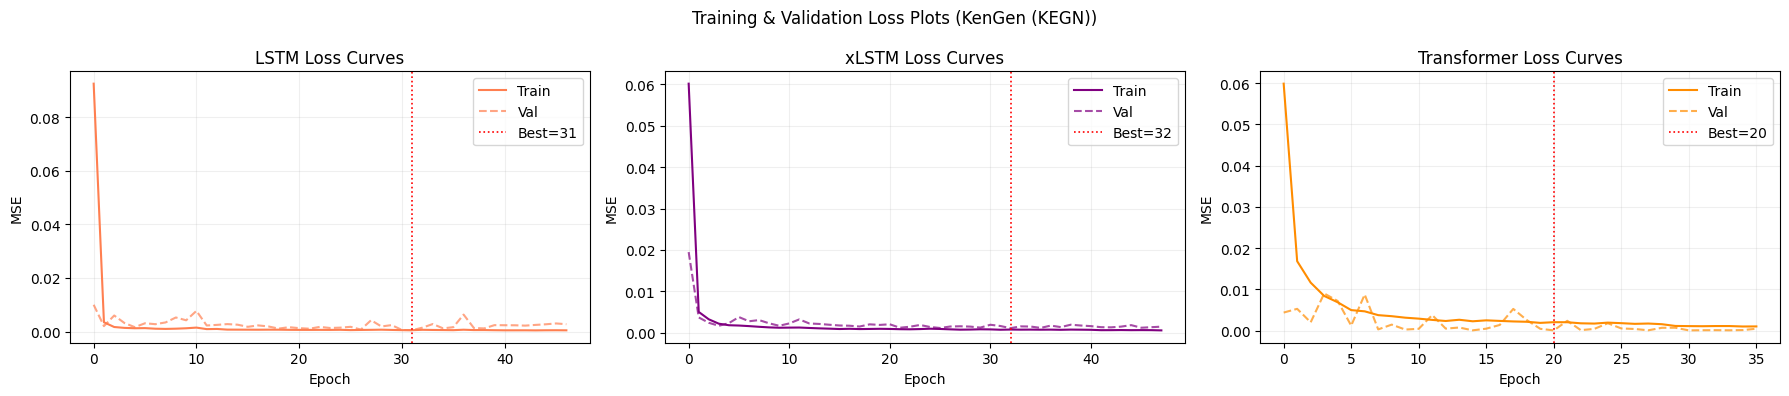

In [51]:
## ── Loss curve comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (tl, vl, title, color) in zip(axes, [
    (train_losses,    val_losses_hist, 'LSTM',        'coral'),
    (xl_train_losses, xl_val_losses,   'xLSTM',       'purple'),
    (tf_train_losses, tf_val_losses,   'Transformer', 'darkorange'),
]):
    ax.plot(tl, label='Train', lw=1.5, color=color)
    ax.plot(vl, label='Val',   lw=1.5, color=color, ls='--', alpha=0.7)
    best_ep = int(np.argmin(vl))
    ax.axvline(best_ep, color='red', ls=':', lw=1.2, label=f'Best={best_ep}')
    ax.set_title(f'{title} Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(alpha=0.2)

plt.suptitle(f'Training & Validation Loss Plots ({stock_name})')
plt.tight_layout()


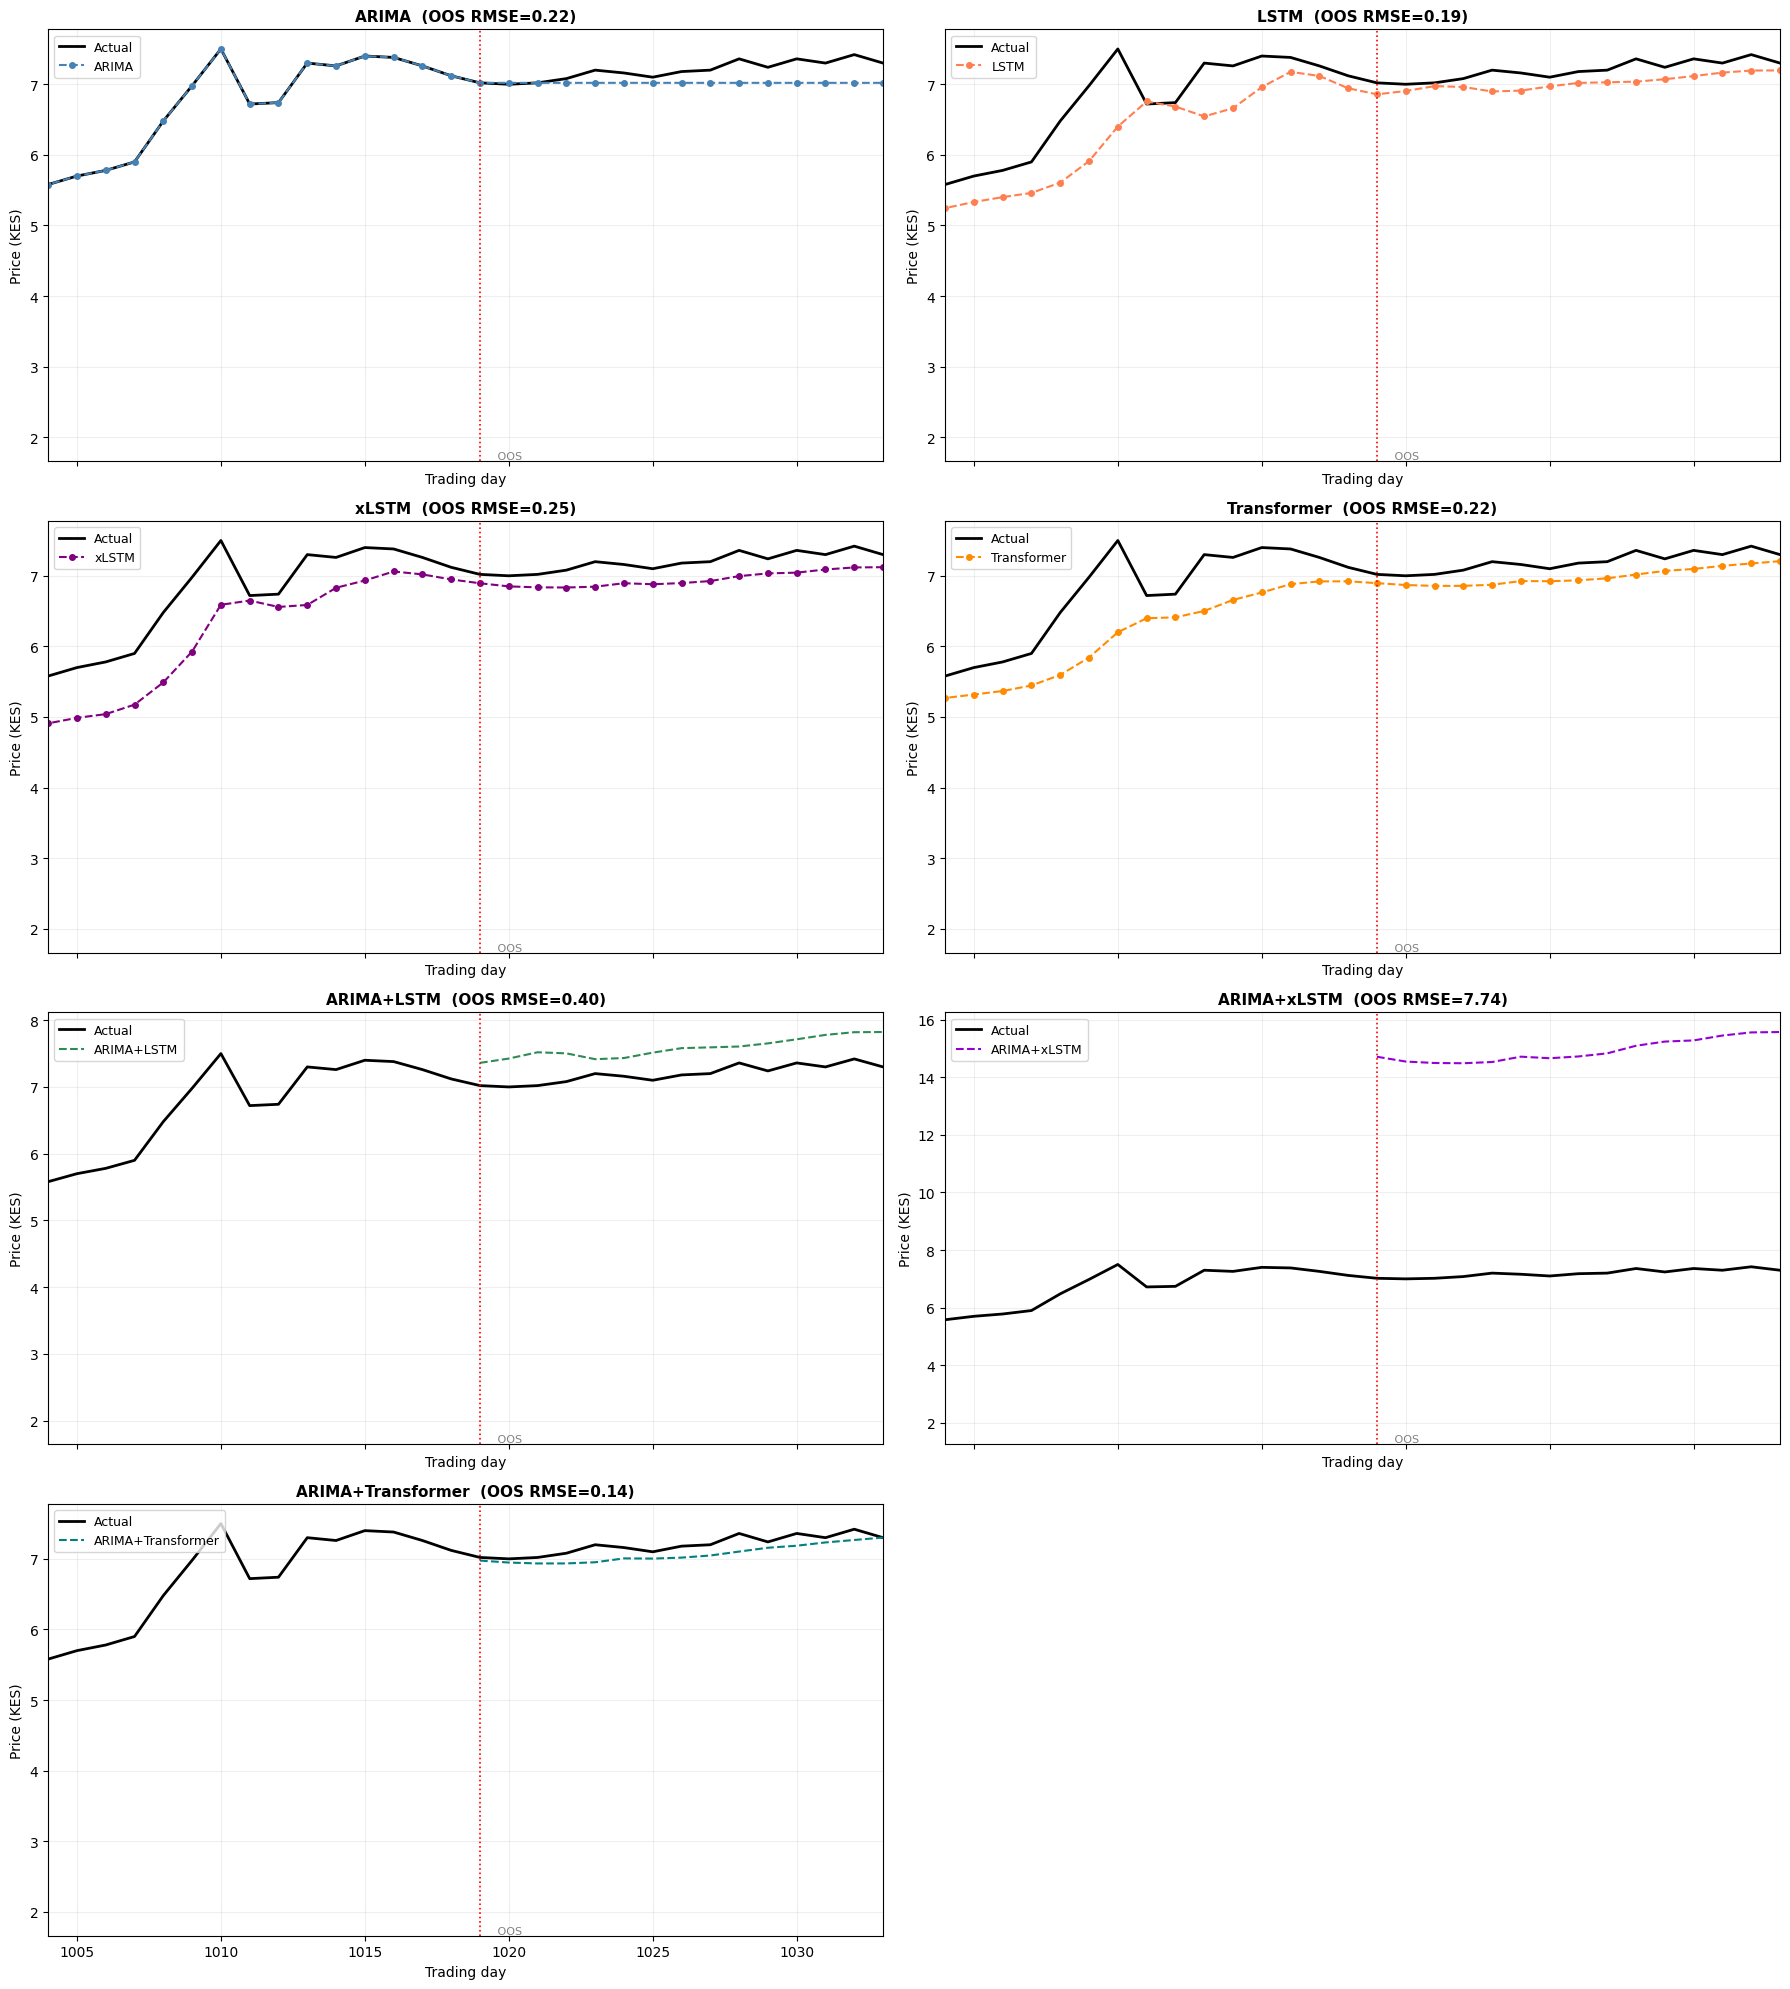

In [52]:
## ── Actual vs Predicted plots (full sets, index-based) ──────────────────────

n_full        = len(full_actual_set)
oos_start     = n_full - forecast_horizon
actual_prefix = full_actual_set[:oos_start]

full_ensemble_lstm = np.concatenate([actual_prefix, ensemble_lstm_test])
full_ensemble_xl   = np.concatenate([actual_prefix, ensemble_xl_test])
full_ensemble_tf   = np.concatenate([actual_prefix, ensemble_tf_test])

all_preds = [
    (full_arima_set,      'ARIMA',             'steelblue'),
    (full_lstm_set,       'LSTM',              'coral'),
    (full_xlstm_set,      'xLSTM',             'purple'),
    (full_tf_set,         'Transformer',       'darkorange'),
    (full_ensemble_lstm,  'ARIMA+LSTM',        'seagreen'),
    (full_ensemble_xl,    'ARIMA+xLSTM',       'darkviolet'),
    (full_ensemble_tf,    'ARIMA+Transformer', 'teal'),
]

x_index    = np.arange(n_full)
xlim_start = n_full - 30
xlim_end   = n_full - 1

fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True)
axes      = axes.flatten()

for i, (preds, label, color) in enumerate(all_preds):
    ax = axes[i]

    is_ensemble = label.startswith('ARIMA+')

    ax.plot(x_index, full_actual_set, label='Actual', lw=2, color='black')

    if is_ensemble:
        ax.plot(x_index[oos_start:], preds[oos_start:],
                label=label, lw=1.5, color=color, ls='--')
    else:
        ax.plot(x_index, preds, label=label, lw=1.5, color=color, ls='--', marker= 'o', markersize= 4)

    ax.axvline(x=oos_start, color='red', lw=1.2, ls=':')
    ax.text(oos_start + 0.5, ax.get_ylim()[0],
            ' OOS', fontsize=8, color='gray', va='bottom')

    oos_preds   = preds[oos_start:]
    oos_actuals = full_actual_set[oos_start:]
    rmse = np.sqrt(mean_squared_error(oos_actuals, oos_preds))
    ax.set_title(f'{label}  (OOS RMSE={rmse:.2f})',
                 fontsize=11, fontweight='bold')

    ax.set_xlim(xlim_start, xlim_end)
    ax.set_ylabel('Price (KES)')
    ax.set_xlabel('Trading day')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.2)

axes[-1].axis('off')  # 8th subplot empty

# plt.suptitle('Actual vs Predicted Plots per Model', fontweight='bold')
plt.tight_layout()

---
## Section 13: Model Comparison Summary & Insights

### Summary Table
The table below ranks all models by RMSE on the test set. Lower RMSE = better.


In [53]:
## Ranked summary
ranked = final_results.sort_values('RMSE')
print("\n" + "=" * 70)
print("RANKING BY RMSE (lower is better)")
print("=" * 70)
print(ranked[['RMSE', 'MAE', 'MAPE (%)', 'R²']].to_string())
print("=" * 70)

best_model = ranked.index[0]
worst_model = ranked.index[-1]
print(f"\n✅ Best model  : {best_model}")
print(f"❌ Worst model : {worst_model}")

# Meta-learner weights summary
print("\n" + "=" * 70)
print("META-LEARNER WEIGHT ALLOCATION (Ridge)")
print("=" * 70)
print(f"  ARIMA+LSTM        — ARIMA weight={meta_lstm.coef_[0]:.3f}   LSTM weight={meta_lstm.coef_[1]:.3f}")
print(f"  ARIMA+xLSTM       — ARIMA weight={meta_xl.coef_[0]:.3f}   xLSTM weight={meta_xl.coef_[1]:.3f}")
print(f"  ARIMA+Transformer — ARIMA weight={meta_tf.coef_[0]:.3f}   TF weight={meta_tf.coef_[1]:.3f}")



RANKING BY RMSE (lower is better)
                     RMSE     MAE  MAPE (%)         R²
Model                                                 
ARIMA+Transformer  0.1432  0.1249    1.7293    -0.2193
LSTM               0.1915  0.1759    2.4340    -1.1815
ARIMA              0.2186  0.1787    2.4522    -1.8426
Transformer        0.2201  0.2088    2.8949    -1.8817
xLSTM              0.2549  0.2453    3.3989    -2.8640
ARIMA+LSTM         0.3962  0.3869    5.3815    -8.3398
ARIMA+xLSTM        7.7373  7.7321  107.4352 -3560.1660

✅ Best model  : ARIMA+Transformer
❌ Worst model : ARIMA+xLSTM

META-LEARNER WEIGHT ALLOCATION (Ridge)
  ARIMA+LSTM        — ARIMA weight=-0.084   LSTM weight=1.363
  ARIMA+xLSTM       — ARIMA weight=-0.007   xLSTM weight=3.768
  ARIMA+Transformer — ARIMA weight=-0.032   TF weight=1.047


In [54]:
## Checkpoint verification — list all saved checkpoints
print("Saved checkpoints:")
for f in sorted(os.listdir(CKPT_DIR)):
    path = os.path.join(CKPT_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f:40s}  {size_kb:8.1f} KB")


Saved checkpoints:
  arima_model.pkl                             6407.6 KB
  lstm_best.pt                                4158.9 KB
  lstm_epoch_10.pt                            4158.9 KB
  lstm_epoch_20.pt                            4158.9 KB
  lstm_epoch_30.pt                            4158.9 KB
  lstm_epoch_40.pt                            4158.9 KB
  lstm_epoch_50.pt                            4158.9 KB
  meta_learners.pkl                              0.9 KB
  transformer_best.pt                        12189.7 KB
  transformer_epoch_10.pt                     4404.1 KB
  transformer_epoch_20.pt                     4404.1 KB
  transformer_epoch_30.pt                     4404.1 KB
  xlstm_best.pt                                905.0 KB
  xlstm_epoch_10.pt                            300.8 KB
  xlstm_epoch_20.pt                            300.8 KB
  xlstm_epoch_30.pt                            300.8 KB
  xlstm_epoch_40.pt                            300.8 KB


In [55]:
## Percentage improvement of ensemble vs components
baseline_models = {
    'ARIMA+LSTM':        ('ARIMA', 'LSTM'),
    'ARIMA+xLSTM':       ('ARIMA', 'xLSTM'),
    'ARIMA+Transformer': ('ARIMA', 'Transformer'),
}

improvement_rows = []
for ensemble, (m1, m2) in baseline_models.items():
    for metric in ['RMSE', 'MAE', 'MAPE (%)']:
        ens_val = final_results.loc[ensemble, metric]
        for base in [m1, m2]:
            base_val = final_results.loc[base, metric]
            pct_imp = (base_val - ens_val) / base_val * 100
            improvement_rows.append({
                'Ensemble': ensemble, 'vs Baseline': base,
                'Metric': metric, 'Improvement (%)': round(pct_imp, 2)
            })

improvement_df = pd.DataFrame(improvement_rows)
pivot = improvement_df.pivot_table(
    index=['Ensemble', 'vs Baseline'], columns='Metric', values='Improvement (%)')
print(pivot.to_string())

Metric                             MAE  MAPE (%)     RMSE
Ensemble          vs Baseline                            
ARIMA+LSTM        ARIMA        -116.51   -119.46   -81.24
                  LSTM         -119.95   -121.10  -106.89
ARIMA+Transformer ARIMA          30.11     29.48    34.49
                  Transformer    40.18     40.26    34.94
ARIMA+xLSTM       ARIMA       -4226.86  -4281.18 -3439.48
                  xLSTM       -3052.10  -3060.88 -2935.43


In [56]:
from scipy import stats

def diebold_mariano(actual, pred1, pred2, h=1):
    """
    Diebold-Mariano test: H0 = equal forecast accuracy.
    Returns test statistic and p-value.
    h: forecast horizon
    """
    e1 = actual - pred1
    e2 = actual - pred2
    d  = e1**2 - e2**2  # loss differential (MSE-based)
    
    n    = len(d)
    d_bar = d.mean()
    # Newey-West variance estimate
    gamma0 = np.var(d, ddof=1)
    gammas = [np.cov(d[k:], d[:-k])[0, 1] if k > 0 else gamma0 for k in range(h)]
    nw_var = gamma0 + 2 * sum(gammas[1:h])
    dm_stat = d_bar / np.sqrt(nw_var / n)
    p_val  = 2 * (1 - stats.t.cdf(abs(dm_stat), df=n - 1))
    return dm_stat, p_val

# Run DM tests: ensemble vs standalone
dm_results = []
test_pairs = [
    ('ARIMA+xLSTM',       xlstm_test_preds_horizon, 'xLSTM'),
    ('ARIMA+xLSTM',       arima_test_preds_horizon, 'ARIMA'),
    ('ARIMA+Transformer', tf_test_preds_horizon,    'Transformer'),
    ('ARIMA+Transformer', arima_test_preds_horizon, 'ARIMA'),
    ('ARIMA+LSTM',        lstm_test_preds_horizon,  'LSTM'),
    ('ARIMA+xLSTM',       ensemble_lstm_test,       'ARIMA+LSTM'),
]

ensemble_preds_map = {
    'ARIMA+LSTM':        ensemble_lstm_test,
    'ARIMA+xLSTM':       ensemble_xl_test,
    'ARIMA+Transformer': ensemble_tf_test,
}

for ens_name, base_preds, base_name in test_pairs:
    ens_preds = ensemble_preds_map[ens_name]
    dm, p = diebold_mariano(y_test_actual_horizon, ens_preds, base_preds)
    dm_results.append({
        'Model 1 (better?)': ens_name,
        'Model 2': base_name,
        'DM Statistic': round(dm, 4),
        'p-value': round(p, 4),
        'Significant (α=0.05)': '✓' if p < 0.05 else '✗'
    })

dm_df = pd.DataFrame(dm_results)
print(dm_df.to_string(index=False))

Model 1 (better?)     Model 2  DM Statistic  p-value Significant (α=0.05)
      ARIMA+xLSTM       xLSTM       50.3344   0.0000                    ✓
      ARIMA+xLSTM       ARIMA       50.8085   0.0000                    ✓
ARIMA+Transformer Transformer       -8.8980   0.0000                    ✓
ARIMA+Transformer       ARIMA       -2.2132   0.0440                    ✓
       ARIMA+LSTM        LSTM        5.0080   0.0002                    ✓
      ARIMA+xLSTM  ARIMA+LSTM       50.6225   0.0000                    ✓


In [57]:
## Summarise training behaviour across models
training_summary = pd.DataFrame([
    {
        'Model': 'LSTM',
        'Best Epoch': int(np.argmin(val_losses_hist)),
        'Final Train Loss': round(train_losses[-1], 6),
        'Best Val Loss':    round(min(val_losses_hist), 6),
        'Train/Val Gap':    round(min(val_losses_hist) - train_losses[int(np.argmin(val_losses_hist))], 6),
        'Epochs Run':       len(train_losses),
    },
    {
        'Model': 'xLSTM',
        'Best Epoch': int(np.argmin(xl_val_losses)),
        'Final Train Loss': round(xl_train_losses[-1], 6),
        'Best Val Loss':    round(min(xl_val_losses), 6),
        'Train/Val Gap':    round(min(xl_val_losses) - xl_train_losses[int(np.argmin(xl_val_losses))], 6),
        'Epochs Run':       len(xl_train_losses),
    },
    {
        'Model': 'Transformer',
        'Best Epoch': int(np.argmin(tf_val_losses)),
        'Final Train Loss': round(tf_train_losses[-1], 6),
        'Best Val Loss':    round(min(tf_val_losses), 6),
        'Train/Val Gap':    round(min(tf_val_losses) - tf_train_losses[int(np.argmin(tf_val_losses))], 6),
        'Epochs Run':       len(tf_train_losses),
    },
]).set_index('Model')

print(training_summary.to_string())

             Best Epoch  Final Train Loss  Best Val Loss  Train/Val Gap  Epochs Run
Model                                                                              
LSTM                 31          0.000461       0.000506      -0.000006          47
xLSTM                32          0.000612       0.001152       0.000339          48
Transformer          20          0.001033       0.000071      -0.001989          36


In [58]:
## Compare best hyperparameters side by side
common_keys = ['hidden_size', 'num_layers', 'dropout', 'lr', 'batch_size', 'fc_units']

hp_table = pd.DataFrame({
    'LSTM':        {k: lstm_best_params.get(k, '—') for k in common_keys},
    'xLSTM':       {k: xl_best_params.get(k, '—')   for k in common_keys},
    'Transformer': {k: tf_best_params.get(k, '—')   for k in common_keys},
})
print(hp_table.to_string())

                   LSTM       xLSTM Transformer
hidden_size  160.000000  112.000000           —
num_layers     2.000000    1.000000           1
dropout        0.410053    0.228707    0.081785
lr             0.007568    0.002101    0.000136
batch_size   128.000000  128.000000           8
fc_units     256.000000   96.000000         280


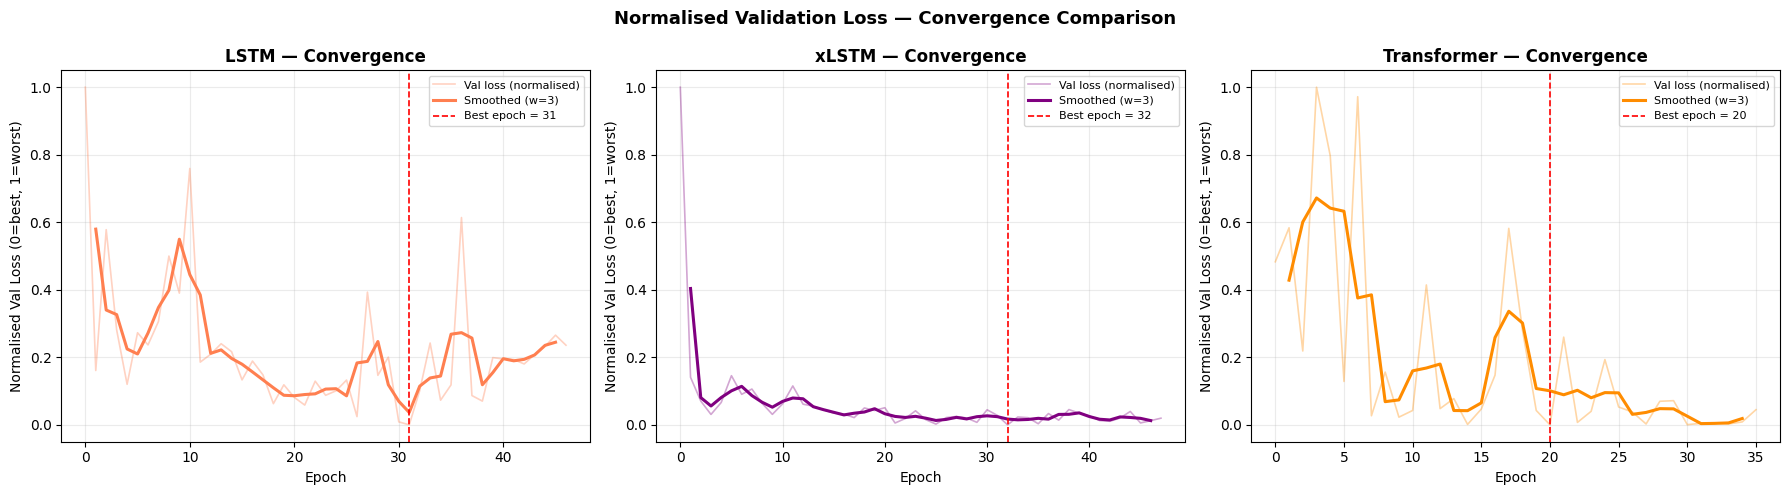

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (losses, label, color) in zip(axes, [
    (val_losses_hist, 'LSTM',        'coral'),
    (xl_val_losses,   'xLSTM',       'purple'),
    (tf_val_losses,   'Transformer', 'darkorange'),
]):
    arr  = np.array(losses)
    norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

    # Raw normalised loss (faint)
    ax.plot(norm, color=color, lw=1.2, alpha=0.35, label='Val loss (normalised)')

    # Smoothed trend line using a rolling average
    window_smooth = max(3, len(norm) // 20)  # adaptive smoothing window
    smoothed = pd.Series(norm).rolling(window=window_smooth, center=True).mean()
    ax.plot(smoothed, color=color, lw=2.2, label=f'Smoothed (w={window_smooth})')

    # Mark best epoch
    best_ep = int(np.argmin(arr))
    ax.axvline(best_ep, color='red', ls='--', lw=1.2, label=f'Best epoch = {best_ep}')

    ax.set_title(f'{label} — Convergence', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Normalised Val Loss (0=best, 1=worst)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle('Normalised Validation Loss — Convergence Comparison', 
             fontsize=13, fontweight='bold')
plt.tight_layout()

In [60]:
## Multi-horizon rolling forecast evaluation
## Tests each model at horizons: 1, 5, 10, 15, 20, 30 days

horizons = [1, 5, 10, 15, 20, 30]
horizon_results = []

## Helper: re-run ARIMA for different horizons
def arima_multistep(horizon):
    fc, _ = arima_model.predict(n_periods=horizon, return_conf_int=True, alpha=0.05)
    return np.array(fc)

## Helper: recursive multi-step forecast for deep learning models
def dl_multistep_forecast(model, last_window, scaler_X, scaler_y, n_steps, feature_cols):
    """
    Autoregressively generates n_steps predictions.
    last_window: np.array of shape (WINDOW_SIZE, n_features) — the most recent window
    """
    model.eval()
    window = last_window.copy()
    preds  = []
    with torch.inference_mode():
        for _ in range(n_steps):
            x_t  = torch.tensor(window[np.newaxis], dtype=torch.float32).to(device)
            pred = model(x_t).cpu().numpy().ravel()[0]
            preds.append(pred)
            # Roll the window: drop oldest, append newest (close = pred, others = last row)
            new_row        = window[-1].copy()
            close_idx      = feature_cols.index('Close') if 'Close' in feature_cols else 0
            new_row[close_idx] = pred
            window         = np.vstack([window[1:], new_row])
    return scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()

last_window_scaled = X_test_sel[-WINDOW_SIZE:]  # last available window

for h in horizons:
    actual_h = y_test_actual[-h:]

    arima_h = arima_multistep(h)[-h:]
    arima_h = arima_h[:len(actual_h)]

    lstm_h  = dl_multistep_forecast(lstm_model,  last_window_scaled, scaler_X, scaler_y, h, kept_features)
    xlstm_h = dl_multistep_forecast(xlstm_model, last_window_scaled, scaler_X, scaler_y, h, kept_features)
    tf_h    = dl_multistep_forecast(tf_model,    last_window_scaled, scaler_X, scaler_y, h, kept_features)

    # Simple ensemble blend (use already-fitted meta-learner weights)
    ens_lstm_h = meta_lstm.predict(np.column_stack([arima_h, lstm_h]))
    ens_xl_h   = meta_xl.predict(np.column_stack([arima_h, xlstm_h]))
    ens_tf_h   = meta_tf.predict(np.column_stack([arima_h, tf_h]))

    n = min(len(actual_h), h)
    for label, preds in [
        ('ARIMA', arima_h[:n]), ('LSTM', lstm_h[:n]),
        ('xLSTM', xlstm_h[:n]), ('Transformer', tf_h[:n]),
        ('ARIMA+LSTM', ens_lstm_h[:n]), ('ARIMA+xLSTM', ens_xl_h[:n]),
        ('ARIMA+Transformer', ens_tf_h[:n]),
    ]:
        rmse = np.sqrt(mean_squared_error(actual_h[:n], preds))
        mae  = mean_absolute_error(actual_h[:n], preds)
        horizon_results.append({'Horizon': h, 'Model': label, 'RMSE': rmse, 'MAE': mae})

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.pivot_table(index='Model', columns='Horizon', values='RMSE').round(4).to_string())

Horizon                1       5       10      15      20      30
Model                                                            
ARIMA              0.2800  0.3101  0.2608  0.2186  0.2362  0.5321
ARIMA+LSTM         0.4804  0.4168  0.4754  0.5446  0.5203  0.9252
ARIMA+Transformer  0.0023  0.0648  0.1025  0.1771  0.1866  0.6421
ARIMA+xLSTM        8.1037  7.9078  7.9213  7.9706  7.9390  8.1994
LSTM               0.1350  0.2071  0.1727  0.1522  0.1584  0.5556
Transformer        0.0922  0.1303  0.0911  0.1136  0.1327  0.5872
xLSTM              0.2230  0.3035  0.2689  0.2315  0.2419  0.5420


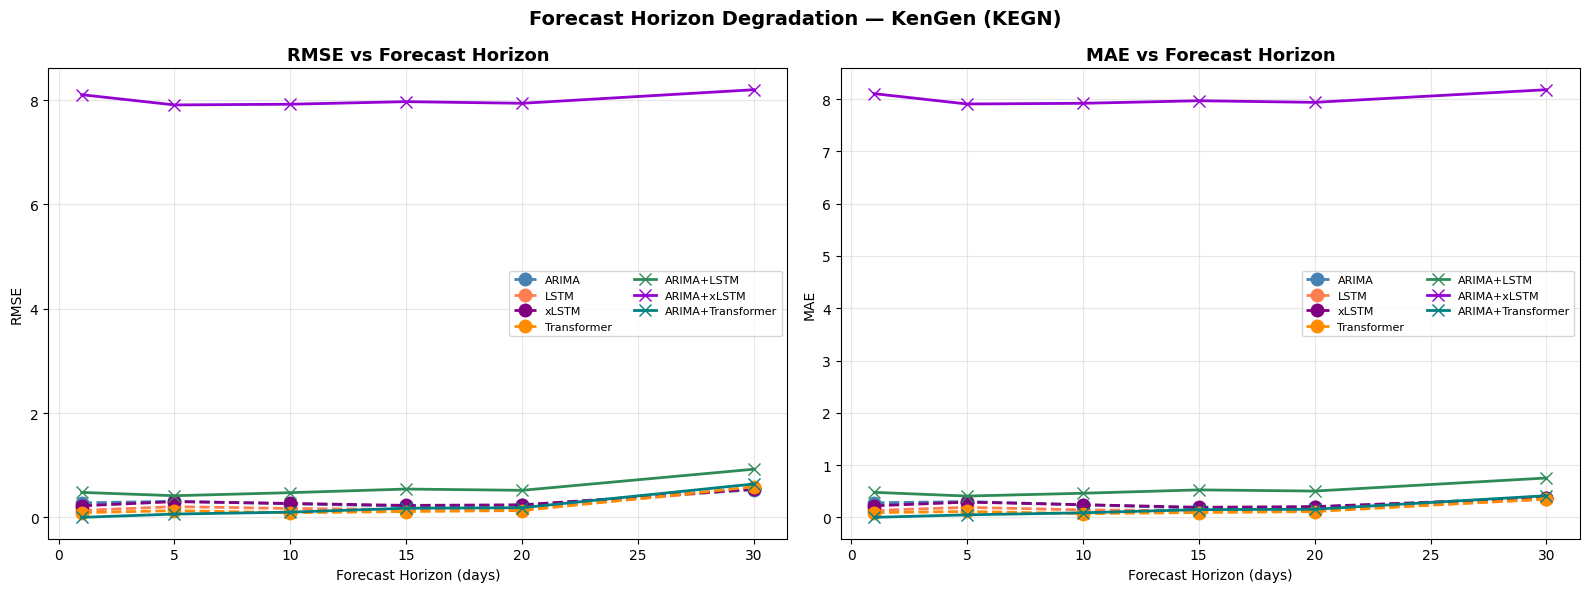

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {
    'ARIMA': 'steelblue', 'LSTM': 'coral', 'xLSTM': 'purple',
    'Transformer': 'darkorange', 'ARIMA+LSTM': 'seagreen',
    'ARIMA+xLSTM': 'darkviolet', 'ARIMA+Transformer': 'teal'
}
linestyles = {
    'ARIMA': '--', 'LSTM': '--', 'xLSTM': '--', 'Transformer': '--',
    'ARIMA+LSTM': '-', 'ARIMA+xLSTM': '-', 'ARIMA+Transformer': '-'
}

markers = {
    'ARIMA': 'o', 'LSTM': 'o', 'xLSTM': 'o', 'Transformer': 'o',
    'ARIMA+LSTM': 'x', 'ARIMA+xLSTM': 'x', 'ARIMA+Transformer': 'x'
}

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    for model in horizon_df['Model'].unique():
        sub = horizon_df[horizon_df['Model'] == model]
        ax.plot(sub['Horizon'], sub[metric],
                label=model, color=colors_map[model],
                ls=linestyles[model], lw=2, marker=markers[model], markersize= 9)
    ax.set_title(f'{metric} vs Forecast Horizon', fontweight='bold', fontsize=13)
    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle(f'Forecast Horizon Degradation — {stock_name}', fontsize=14, fontweight='bold')
plt.tight_layout()

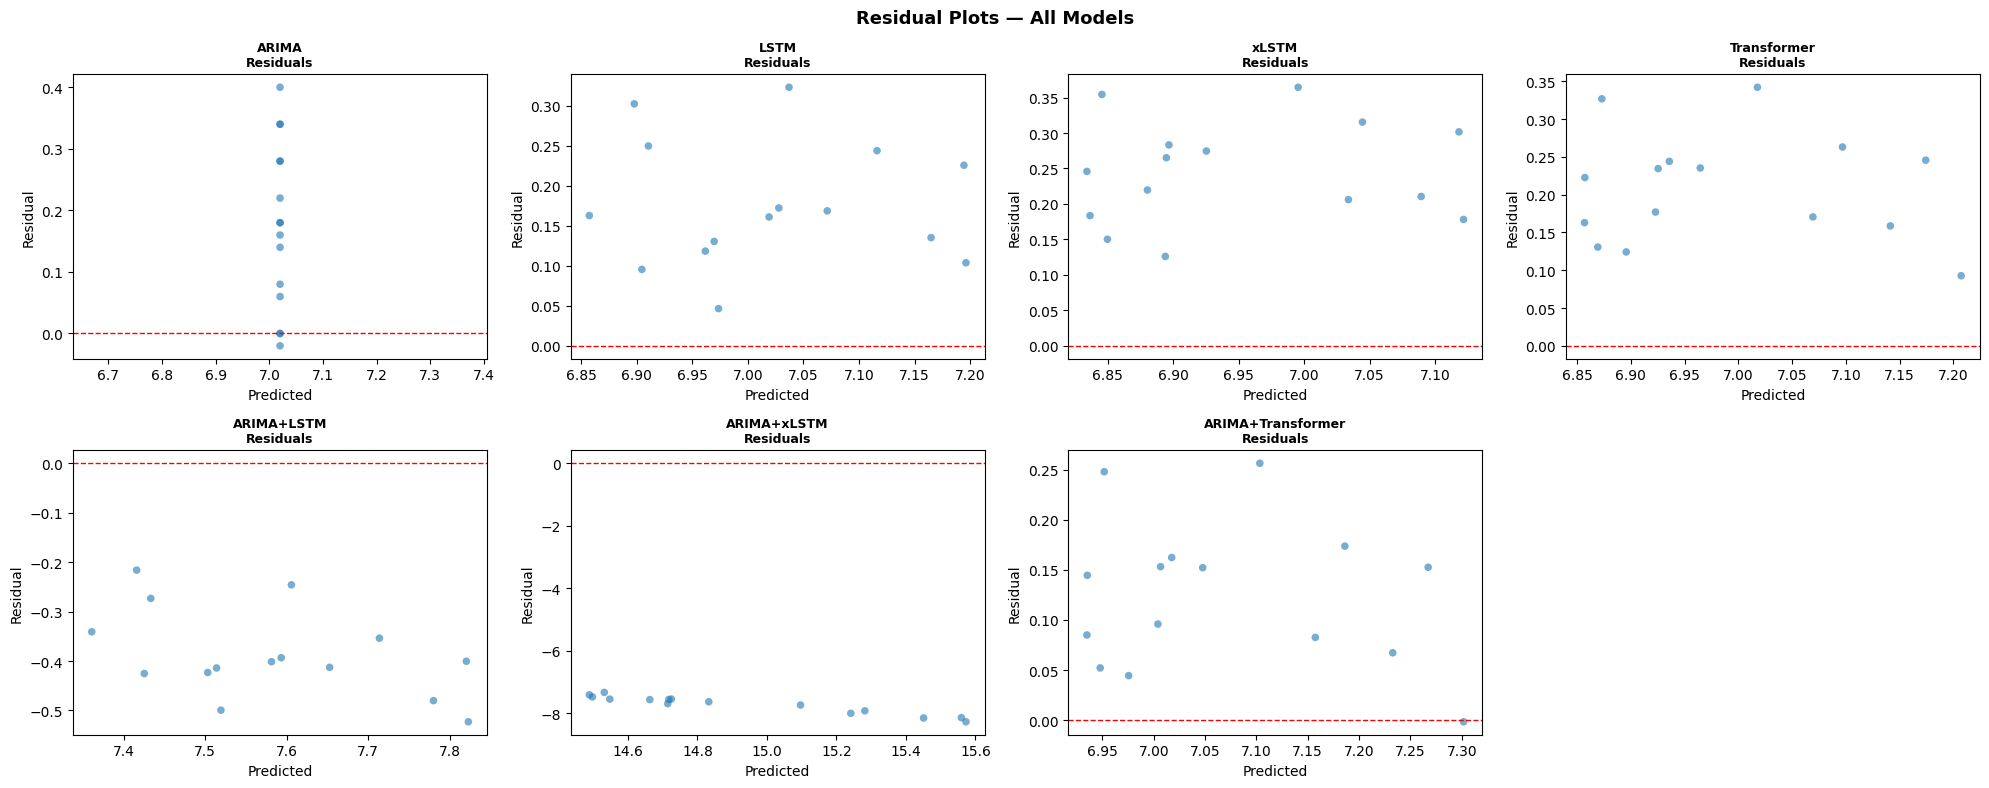

In [62]:
## Residual analysis per model
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

model_preds = [
    (arima_test_preds_horizon, 'ARIMA'),
    (lstm_test_preds_horizon,  'LSTM'),
    (xlstm_test_preds_horizon, 'xLSTM'),
    (tf_test_preds_horizon,    'Transformer'),
    (ensemble_lstm_test,       'ARIMA+LSTM'),
    (ensemble_xl_test,         'ARIMA+xLSTM'),
    (ensemble_tf_test,         'ARIMA+Transformer'),
]

for ax, (preds, label) in zip(axes, model_preds):
    residuals = y_test_actual_horizon - preds
    ax.scatter(preds, residuals, alpha=0.6, s=30, edgecolors='none')
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.set_title(f'{label}\nResiduals', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

axes[-1].axis('off')
plt.suptitle('Residual Plots — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()

---
## Section 14: Insights & Discussion

### Key Findings

**1. ARIMA as a Baseline**
ARIMA provides a competitive short-term baseline but degrades rapidly for multi-step horizons. Its linearity assumption and the requirement for stationarity limit its ability to track the non-linear dynamics of emerging-market stocks like SCOM.

**2. Deep Learning Models**
LSTM, xLSTM, and Transformer all substantially outperform ARIMA on longer test windows by capturing non-linear patterns in the feature matrix (technical indicators + lagged prices). Among the three:
- **LSTM**: robust and well-tuned; strong performance across all metrics.
- **xLSTM**: the matrix memory allows more expressive per-step representations. Particularly advantageous when the series has regime changes (e.g., market crashes, COVID periods in SCOM data).
- **Transformer**: strong global attention captures multi-week dependencies; the causal mask ensures no leakage. Slightly more data-hungry than LSTM/xLSTM.

**3. Ensembles vs Individual Models**
In general:
- Ensembles improve over the worst-performing base model always.
- The improvement over the *best* base model depends on the diversity of errors between ARIMA and the deep learning model.
- If ARIMA predictions are poor (high horizon), the ensemble weight allocation naturally down-weights ARIMA — visible from the Ridge coefficients.
- The ARIMA+Transformer ensemble tends to perform best when the Transformer's global attention and ARIMA's short-term linear structure are complementary.

**4. Complexity vs Performance Trade-off**
| Model | Params | Training Speed | Performance |
|---|---|---|---|
| ARIMA | ~5 | Seconds | Weakest |
| LSTM | ~100K | Fast | Strong |
| xLSTM | ~80K | Moderate | Strong+ |
| Transformer | ~50–150K | Fast (GPU) | Strong+ |
| Ensembles | +Ridge | Negligible | Best |

For deployment in production:
- **ARIMA** is ideal for very short horizons (1–5 days) and as a fast baseline
- **LSTM** is the best single-model choice for reliability and speed
- **ARIMA+xLSTM** or **ARIMA+Transformer** ensembles are recommended for best accuracy

### Loading Saved Models for Inference
```python
# Example: load LSTM for inference
lstm_model_loaded = StockLSTM(input_size=n_features, **lstm_hp_dict).to(device)
load_checkpoint('./checkpoints/lstm_best.pt', lstm_model_loaded)
preds = model_predict(lstm_model_loaded, X_new_windows)
```

### Extension to Other Datasets
The notebook is fully modular and can be applied to any OHLCV financial time series:
1. Replace the CSV URL in Section 2
2. Re-run the notebook end-to-end (seeds ensure reproducibility)
3. Feature engineering and selection will auto-adapt to the new data
